# Deterministiske Beslutningsprocesser / Deterministic Decision Processes (DDPs)

**Kursus / Course:** DM887 — Reinforcement Learning, SDU  
**Forelæsning / Lecture:** 1 & 2 — Mannor Book Chapters 1–4  
**Emne / Topic:** Deterministiske dynamiske systemer, endelig-horisont optimering, dynamisk programmering  
**Topic:** Deterministic dynamic systems, finite-horizon optimization, dynamic programming

## 1. Diskrete dynamiske systemer / Discrete Dynamic Systems

**DK:** Et deterministisk dynamisk system beskriver, hvordan en tilstand ændrer sig over tid baseret på de handlinger, agenten tager. Der er **ingen tilfældighed** — givet en tilstand og en handling er næste tilstand fuldstændig bestemt.

**EN:** A deterministic dynamic system describes how a state changes over time based on the actions the agent takes. There is **no randomness** — given a state and an action, the next state is completely determined.

### Formel definition / Formal definition

$$s_{t+1} = f_t(s_t, a_t), \quad t = 0, 1, \ldots, T-1$$

| Symbol | Navn (DK) | Name (EN) | Betydning |
|--------|-----------|-----------|-----------|
| $s_t \in \mathcal{S}_t$ | Tilstand ved tid $t$ | State at time $t$ | Systemets tilstand på tidspunkt $t$ / The system state at time $t$ |
| $a_t \in \mathcal{A}_t$ | Handling ved tid $t$ | Action at time $t$ | Agentens valg på tidspunkt $t$ / The agent's choice at time $t$ |
| $f_t: \mathcal{S}_t \times \mathcal{A}_t \to \mathcal{S}_{t+1}$ | Overgangsfunktion | Transition function | Deterministisk funktion der giver næste tilstand / Deterministic function giving next state |
| $T$ | Tidshorisont | Time horizon | Antal trin i processen / Number of steps in the process |

**Tidsinvariant system / Time-invariant system:** Hvis $f_t = f$, $\mathcal{S}_t = \mathcal{S}$, og $\mathcal{A}_t = \mathcal{A}$ for alle $t$:

$$s_{t+1} = f(s_t, a_t)$$

**DK:** I et tidsinvariant system afhænger dynamikken ikke af *hvornår* vi er, kun af *hvor* vi er og *hvad* vi gør.

**EN:** In a time-invariant system, the dynamics do not depend on *when* we are, only on *where* we are and *what* we do.

## 2. Gangbare stier / Feasible Paths

**DK:** En **gangbar sti** (feasible path) er en sekvens af tilstande og handlinger, der respekterer overgangsfunktionen.

**EN:** A **feasible path** is a sequence of states and actions that respects the transition function.

$$h_T = (s_0, a_0, s_1, a_1, \ldots, s_{T-1}, a_{T-1}, s_T)$$

hvor / where $a_t \in \mathcal{A}_t$ og / and $s_{t+1} = f_t(s_t, a_t)$ for $t \in \{0, \ldots, T-1\}$.

**DK:** Stien angiver én bestemt rejse gennem tilstandsrummet. Den specificerer kun handlinger for de tilstande, der *faktisk* besøges.

**EN:** The path describes one specific journey through the state space. It only specifies actions for the states that are *actually* visited.

## 3. Total belønning og den endelige horisont-opgave / Total Reward and the Finite-Horizon Problem

**DK:** Vi ønsker at finde den sti, der giver **størst total belønning** over hele horisonten.

**EN:** We want to find the path that gives the **largest total reward** over the entire horizon.

### Kumulativ belønning / Cumulative reward

$$V_T(h_T) = \sum_{t=0}^{T-1} r_t(s_t, a_t) + r_T(s_T)$$

| Symbol | Navn (DK) | Name (EN) | Betydning |
|--------|-----------|-----------|-----------|
| $V_T(h_T)$ | Total belønning for sti $h_T$ | Total reward for path $h_T$ | Summen af alle belønninger langs stien / Sum of all rewards along the path |
| $r_t(s_t, a_t)$ | Trinbelønning | Stage reward | Belønning for at vælge handling $a_t$ i tilstand $s_t$ / Reward for choosing action $a_t$ in state $s_t$ |
| $r_T(s_T)$ | Terminalbelønning | Terminal reward | Belønning for at ende i tilstand $s_T$ / Reward for ending in state $s_T$ |

### Diskonteret belønning / Discounted Reward

**DK:** I mange problemer vægtes fremtidige belønninger lavere end umiddelbare belønninger via en **diskonteringsfaktor** $\gamma \in [0, 1)$:

**EN:** In many problems, future rewards are weighted less than immediate rewards via a **discount factor** $\gamma \in [0, 1)$:

$$V_T^\gamma(h_T) = \sum_{t=0}^{T-1} \gamma^t \, r_t(s_t, a_t) + \gamma^T \, r_T(s_T)$$

**DK:** I denne notebook bruger vi $\gamma = 1$ (ingen diskontering) — alle belønninger tæller lige meget. Diskontering ($\gamma < 1$) bliver centralt i notebook 4 om *discounted decision processes*.

**EN:** In this notebook we use $\gamma = 1$ (no discounting) — all rewards count equally. Discounting ($\gamma < 1$) becomes central in notebook 4 on *discounted decision processes*.

### Optimeringsopgaven / The optimization problem

$$h_T^* = \arg\max_{h_T} V_T(h_T)$$

**DK:** Find den gangbare sti $h_T^*$ der maksimerer den totale belønning. Denne sti kaldes den **optimale sti** fra $s_0$.

**EN:** Find the feasible path $h_T^*$ that maximizes total reward. This path is called the **optimal path** from $s_0$.

## 4. Politikker / Policies

**DK:** En **politik** specificerer en handling for *enhver mulig* tilstand — ikke kun dem på én bestemt sti. Dette er forskellen mellem en politik og en sti.

**EN:** A **policy** specifies an action for *every possible* state — not just those on one particular path. This is the difference between a policy and a path.

### Typer af deterministiske politikker / Types of deterministic policies

| Type | Notation | DK | EN |
|------|----------|----|----|
| Historiafhængig | $a_t = \pi_t(h_t)$, $\pi_t \in \Pi_{HD}$ | Handlingen afhænger af hele historien $(s_0,a_0,...,s_t)$ | The action depends on the full history |
| Markov | $a_t = \pi_t(s_t)$, $\pi_t \in \Pi_{MD}$ | Handlingen afhænger kun af den nuværende tilstand | The action depends only on the current state |
| Stationær | $a_t = \pi(s_t)$, $\pi \in \Pi_{SD}$ | Markov-politik der ikke ændrer sig over tid | Markov policy that doesn't change over time |

$$\Pi_{HD} \supset \Pi_{MD} \supset \Pi_{SD}$$

**DK:** For DDPs med endelig horisont er Markov-politikker tilstrækkelige — vi behøver ikke kigge på hele historien.

**EN:** For finite-horizon DDPs, Markov policies are sufficient — we don't need to look at the full history.

### Nøgleresultat / Key result

**DK:** For enhver stokastisk politik $\pi$ findes der en deterministisk Markov-politik $\pi'$ der er mindst lige så god:

**EN:** For any stochastic policy $\pi$, there exists a deterministic Markov policy $\pi'$ that is at least as good:

$$E[V^{\pi'}(s_0)] \geq E[V^{\pi}(s_0)]$$

**DK:** Dette bevises via baglæns induktion: i hvert trin kan vi erstatte en blanding af handlinger med den bedste handling.

**EN:** This is proven via backward induction: at each step, we can replace a mixture of actions with the best single action.

## 5. Dynamisk Programmering (DP) og Bellmans Princip / Dynamic Programming and Bellman's Principle

**DK:** Dynamisk programmering løser optimeringsproblemet ved at bryde det ned i $T$ sekventielle ét-trins problemer, startende fra det **sidste** trin og gående **baglæns**. Dette kaldes **baglæns induktion** (backward induction).

**EN:** Dynamic programming solves the optimization problem by breaking it into $T$ sequential single-step problems, starting from the **last** step and going **backwards**. This is called **backward induction**.

### Bellmans Optimalitetsprincip / Bellman's Principle of Optimality

> **DK:** Halen af en optimal politik er optimal for haleproblemet.  
> **EN:** The tail of an optimal policy is optimal for the tail problem.

**DK:** Hvis den samlede optimale sti går igennem tilstand $s$ på tidspunkt $t$, så er den resterende del af stien (fra $s$ og fremad) også optimal for delproblemet der starter i $s$ ved tid $t$.

**EN:** If the overall optimal path goes through state $s$ at time $t$, then the remaining portion (from $s$ onward) is also optimal for the sub-problem starting at $s$ at time $t$.

### DP-algoritmen / The DP Algorithm

**Trin 1 (Initialisering / Initialization):**
$$V_T(s) = r_T(s), \quad \forall s \in \mathcal{S}_T$$

**Trin 2 (Baglæns rekursion / Backward recursion):** For $t = T-1, T-2, \ldots, 0$:
$$V_t(s) = \max_{a \in \mathcal{A}_t} \Big\{ r_t(s, a) + V_{t+1}\big(f_t(s, a)\big) \Big\}, \quad \forall s \in \mathcal{S}_t$$

**Trin 3 (Optimal politik / Optimal policy):**
$$\pi_t^*(s) \in \arg\max_{a \in \mathcal{A}_t} \Big\{ r_t(s, a) + V_{t+1}\big(f_t(s, a)\big) \Big\}$$

**DK:** Bellman-ligningen her er: "Værdien af en tilstand = den bedste umiddelbare belønning + værdien af den resulterende næste tilstand."

**EN:** The Bellman equation here says: "The value of a state = the best immediate reward + the value of the resulting next state."

### Kompleksitet / Complexity

| Metode / Method | Kompleksitet / Complexity |
|-----------------|--------------------------|
| Brute-force (alle politikker / all policies) | $O(m^{nT})$ — eksponentiel / exponential |
| Dynamisk programmering / Dynamic programming | $O(T \cdot n \cdot m)$ — polynomiel / polynomial |

**DK:** Med $n = m = T = 10$ er brute-force $10^{100}$ operationer. DP bruger kun $10^3 = 1000$.

**EN:** With $n = m = T = 10$, brute-force requires $10^{100}$ operations. DP uses only $10^3 = 1000$.

## 6. Gennemsnitlig belønning / Average Reward Criterion

**DK:** Et alternativt kriterium hvor vi maksimerer den gennemsnitlige belønning per trin over en uendelig horisont:

**EN:** An alternative criterion where we maximize the average reward per step over an infinite horizon:

$$R_{\text{avg}} = \lim_{T \to \infty} \frac{1}{T} \sum_{t=0}^{T} r_t(s_t, a_t)$$

**DK:** For enhver DDP opnås den optimale gennemsnitlige belønning af en politik, der cykler rundt i en simpel cyklus. Den maksimale gennemsnitlige belønning er totalbelønningen af denne cyklus divideret med dens længde.

**EN:** For any DDP, the optimal average reward is reached by a policy that cycles around a simple cycle. The maximum average reward is the total reward of that cycle divided by its length.

---

# Eksempler / Examples

De følgende eksempler dækker forskellige aspekter af DDPs — fra simple grafer til virkelige anvendelser.

The following examples cover different aspects of DDPs — from simple graphs to real-world applications.

## Eksempel 1: Simpel beslutningsgraf med 2 trin / Simple 2-Step Decision Graph

**Scenarie / Scenario:** En robot starter i tilstand $A$ og skal vælge handlinger over 2 trin ($T=2$). Vi beregner den optimale sti via DP.

A robot starts in state $A$ and must choose actions over 2 steps ($T=2$). We compute the optimal path via DP.

**Tilstande / States:** $\mathcal{S}_0 = \{A\}$, $\mathcal{S}_1 = \{B, C\}$, $\mathcal{S}_2 = \{D, E, F\}$

**Overgange og belønninger / Transitions and rewards:**
- $f_0(A, \text{left}) = B$, $r_0(A, \text{left}) = 3$
- $f_0(A, \text{right}) = C$, $r_0(A, \text{right}) = 1$
- $f_1(B, \text{left}) = D$, $r_1(B, \text{left}) = 2$
- $f_1(B, \text{right}) = E$, $r_1(B, \text{right}) = 7$
- $f_1(C, \text{left}) = E$, $r_1(C, \text{left}) = 10$
- $f_1(C, \text{right}) = F$, $r_1(C, \text{right}) = 4$

**Terminal-belønninger / Terminal rewards:** $r_2(D) = 0, \; r_2(E) = 0, \; r_2(F) = 0$

### DP baglæns / DP Backward

**Trin 1:** $V_2(s) = r_2(s) = 0$ for alle terminaltilstande.

**Trin 2:** $t = 1$
$$V_1(B) = \max\big\{r_1(B,L) + V_2(D),\; r_1(B,R) + V_2(E)\big\} = \max\{2+0,\; 7+0\} = 7 \quad (\text{vælg right})$$
$$V_1(C) = \max\big\{r_1(C,L) + V_2(E),\; r_1(C,R) + V_2(F)\big\} = \max\{10+0,\; 4+0\} = 10 \quad (\text{vælg left})$$

**Trin 3:** $t = 0$
$$V_0(A) = \max\big\{r_0(A,L) + V_1(B),\; r_0(A,R) + V_1(C)\big\} = \max\{3+7,\; 1+10\} = 11 \quad (\text{vælg right})$$

**Optimal politik / Optimal policy:** $\pi_0^*(A) = \text{right}$, $\pi_1^*(C) = \text{left}$

**Optimal sti / Optimal path:** $A \xrightarrow{R} C \xrightarrow{L} E$ med total belønning / with total reward $= 1 + 10 + 0 = 11$

### 🌳 Visuel oversigt / Visual Overview — Eksempel 1

```mermaid
graph TD
    A["🟡 A (start)"] -->|"L, r=3"| B["B"]
    A -->|"R, r=1 ✅"| C["C"]
    B -->|"L, r=2"| D["D (r_T=0)"]
    B -->|"R, r=7"| E1["E (r_T=0)"]
    C -->|"L, r=10 ✅"| E2["E (r_T=0)"]
    C -->|"R, r=4"| F["F (r_T=0)"]

    style A fill:#FFD700,stroke:#333,color:#333
    style C fill:#90EE90,stroke:#333,color:#333
    style E2 fill:#90EE90,stroke:#333,color:#333
```

**Læsning / How to read:** Gul = start. Grøn = optimal sti. Hver kant viser handling og belønning. DP vælger $A \to C \to E$ (total 11), ikke $A \to B \to E$ (total 10).

### LaTeX graf / LaTeX Graph

$$
\begin{array}{ccccc}
& & \boxed{A} & & \\
& \swarrow^{L,\;r=3} & & \searrow^{\mathbf{R,\;r=1\;\checkmark}} & \\
\boxed{B} & & & & \boxed{\mathbf{C}} \\
\swarrow^{L,\;r=2} \quad \searrow^{R,\;r=7} & & & \swarrow^{\mathbf{L,\;r=10\;\checkmark}} \quad \searrow^{R,\;r=4} & \\
\boxed{D} \qquad \boxed{E} & & & \boxed{\mathbf{E}} \qquad \boxed{F} &
\end{array}
$$

$$
\text{Optimal sti: } A \xrightarrow{R,\;r=1} C \xrightarrow{L,\;r=10} E \;,\quad V_0(A) = 1 + 10 + 0 = \mathbf{11}
$$

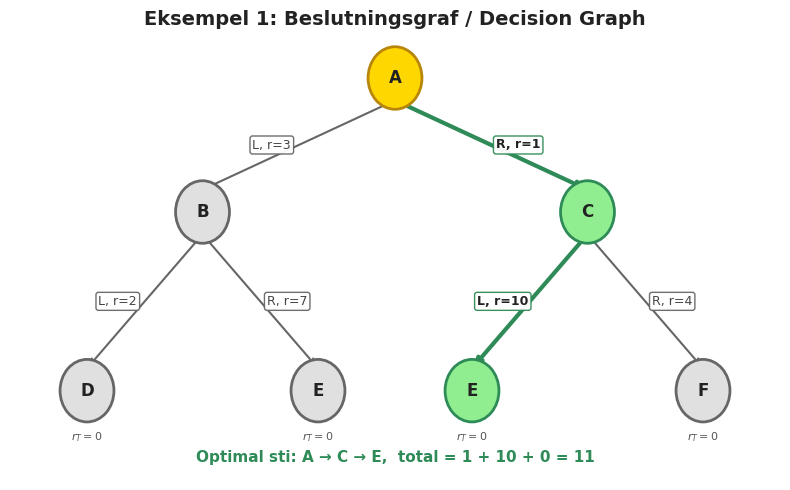

In [32]:
# Eksempel 1: Visuel graf / Visual graph — Decision tree
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.set_xlim(-1, 9)
ax.set_ylim(-0.5, 4.5)
ax.axis('off')
ax.set_title('Eksempel 1: Beslutningsgraf / Decision Graph', fontsize=14, fontweight='bold', color='#222')

# Node positions
nodes = {'A': (4, 4), 'B': (1.5, 2.5), 'C': (6.5, 2.5),
         'D': (0, 0.5), 'E_B': (3, 0.5), 'E_C': (5, 0.5), 'F': (8, 0.5)}

edges = [
    ('A', 'B', 'L, r=3', False),
    ('A', 'C', 'R, r=1', True),
    ('B', 'D', 'L, r=2', False),
    ('B', 'E_B', 'R, r=7', False),
    ('C', 'E_C', 'L, r=10', True),
    ('C', 'F', 'R, r=4', False),
]

for src, dst, label, optimal in edges:
    x0, y0 = nodes[src]
    x1, y1 = nodes[dst]
    color = '#2E8B57' if optimal else '#666666'
    lw = 3 if optimal else 1.5
    ax.annotate('', xy=(x1, y1 + 0.25), xytext=(x0, y0 - 0.25),
                arrowprops=dict(arrowstyle='->', color=color, lw=lw))
    mx, my = (x0 + x1) / 2, (y0 + y1) / 2
    offset = -0.35 if x1 < x0 else 0.35
    ax.text(mx + offset, my, label, fontsize=9, ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor=color, alpha=0.95),
            color='#222' if optimal else '#444', fontweight='bold' if optimal else 'normal')

for name, (x, y) in nodes.items():
    display = name.replace('_B', '').replace('_C', '')
    if name == 'A':
        fc, ec = '#FFD700', '#B8860B'
    elif name in ('C', 'E_C'):
        fc, ec = '#90EE90', '#2E8B57'
    else:
        fc, ec = '#E0E0E0', '#666666'
    circle = plt.Circle((x, y), 0.35, facecolor=fc, edgecolor=ec, linewidth=2, zorder=5)
    ax.add_patch(circle)
    ax.text(x, y, display, ha='center', va='center', fontsize=12, fontweight='bold', color='#222', zorder=6)

for name in ['D', 'E_B', 'E_C', 'F']:
    x, y = nodes[name]
    ax.text(x, y - 0.55, '$r_T=0$', ha='center', fontsize=8, color='#555')

ax.text(4, -0.3, 'Optimal sti: A → C → E,  total = 1 + 10 + 0 = 11',
        ha='center', fontsize=11, fontweight='bold', color='#2E8B57')

plt.tight_layout()
plt.show()

In [43]:
# Eksempel 1: Simpel 2-trins beslutningsgraf / Simple 2-step decision graph

# Define transitions: (state, action) -> (next_state, reward)
transitions = {
    ("A", "left"):  ("B", 3),
    ("A", "right"): ("C", 1),
    ("B", "left"):  ("D", 2),
    ("B", "right"): ("E", 7),
    ("C", "left"):  ("E", 10),
    ("C", "right"): ("F", 4),
}

terminal_rewards = {"D": 0, "E": 0, "F": 0}
stages = {0: ["A"], 1: ["B", "C"], 2: ["D", "E", "F"]}
actions = {0: ["left", "right"], 1: ["left", "right"]}
T = 2

# DP backward induction
V = {s: terminal_rewards[s] for s in stages[T]}  # Step 1: terminal values
policy = {}

for t in range(T - 1, -1, -1):
    for s in stages[t]:
        best_val, best_act = float("-inf"), None
        for a in actions[t]:
            s_next, r = transitions[(s, a)]
            val = r + V[s_next]
            if val > best_val:
                best_val, best_act = val, a
        V[s] = best_val
        policy[(t, s)] = best_act

# Print results
print("=== Værdifunktioner / Value functions ===")
for t in range(T + 1):
    for s in stages[t]:
        print(f"  V_{t}({s}) = {V[s]}")

print(f"\n=== Optimal politik / Optimal policy ===")
for (t, s), a in sorted(policy.items()):
    print(f"  π*_{t}({s}) = {a}")

# Trace optimal path
s = "A"
path = [s]
total_reward = 0
for t in range(T):
    a = policy[(t, s)]
    s_next, r = transitions[(s, a)]
    total_reward += r
    path.append(f"--{a}-->  {s_next}")
    s = s_next
total_reward += terminal_rewards[s]

print(f"\n=== Optimal sti / Optimal path ===")
print(f"  {'  '.join(path)}")
print(f"  Total belønning / Total reward = {total_reward}")

=== Værdifunktioner / Value functions ===
  V_0(A) = 11
  V_1(B) = 7
  V_1(C) = 10
  V_2(D) = 0
  V_2(E) = 0
  V_2(F) = 0

=== Optimal politik / Optimal policy ===
  π*_0(A) = right
  π*_1(B) = right
  π*_1(C) = left

=== Optimal sti / Optimal path ===
  A  --right-->  C  --left-->  E
  Total belønning / Total reward = 11


### ✅ Konklusion / Conclusion — Eksempel 1

**Resultater fra outputtet / Results from output:**
- $V_0(A) = 11$ — den maksimale belønning vi kan opnå fra starttilstand $A$.
- **Optimal politik:** $\pi_0^*(A) = \text{right}$, $\pi_1^*(C) = \text{left}$
- **Optimal sti:** $A \xrightarrow{R} C \xrightarrow{L} E$, total belønning $= 1 + 10 + 0 = 11$

**DK:** Selvom handlingen "left" fra $A$ giver en umiddelbar belønning på 3 (mod 1 for "right"), er den samlede belønning bedre ved at vælge "right" først — fordi $C$ har adgang til den meget værdifulde handling $C \xrightarrow{L} E$ med belønning 10. DP undgår den **grådige fejl** (at vælge den bedste umiddelbare belønning) ved at kigge fremad via baglæns induktion.

**EN:** Although "left" from $A$ gives an immediate reward of 3 (vs. 1 for "right"), the total reward is better choosing "right" first — because $C$ has access to the highly valuable action $C \to E$ with reward 10. DP avoids the **greedy mistake** by looking ahead via backward induction.

> **Nøgleindsigt / Key insight:** DP vælger ikke den handling der ser bedst ud *nu*, men den handling der fører til det bedste *samlede* resultat.

## Eksempel 2: Korteste vej i et gitter / Shortest Path on a Grid (Real-World: GPS Navigation)

**Scenarie / Scenario:** En leveringsbil skal køre fra position $(0,0)$ til $(2,2)$ i et $3 \times 3$ gitter. Handlinger er "op" og "højre". Belønningen er negativ (= kostnad) og repræsenterer brændstofforbrug.

A delivery truck must drive from $(0,0)$ to $(2,2)$ on a $3 \times 3$ grid. Actions are "up" and "right". Reward is negative (= cost) representing fuel consumption.

**DK:** Vi bruger negative belønninger — at maksimere den totale belønning svarer til at minimere den totale kostnad.

**EN:** We use negative rewards — maximizing total reward corresponds to minimizing total cost.

**Setup:** $T = 4$ trin (vi skal gå 2 op + 2 til højre)

**Overgangsfunktion / Transition function:**
- $f(s, \text{right}) = (s_x + 1, s_y)$ hvis $s_x < 2$
- $f(s, \text{up}) = (s_x, s_y + 1)$ hvis $s_y < 2$

**Belønninger (kostnad) / Rewards (cost):**

| Fra / From | Handling / Action | Belønning / Reward |
|------------|-------------------|--------------------|
| $(0,0)$ | right | $-1$ |
| $(0,0)$ | up | $-3$ |
| $(1,0)$ | right | $-2$ |
| $(1,0)$ | up | $-1$ |
| $(0,1)$ | right | $-1$ |
| $(0,1)$ | up | $-2$ |
| ... | ... | ... |

**DP:** Starter fra terminaltilstand $(2,2)$ med $V(2,2) = 0$ og regner baglæns. Den optimale rute undgår de dyre kanter.

Starts from terminal state $(2,2)$ with $V(2,2) = 0$ and computes backwards. The optimal route avoids expensive edges.

### 🗺️ Visuel oversigt / Visual Overview — Eksempel 2

```
         Kostnad / cost for each edge (negative belønning)

        (0,2)───1───(1,2)───1───⭐(2,2) MÅL/GOAL
          │           │           │
          2           1           2
          │           │           │
        (0,1)───1───(1,1)───4───(2,1)
          │           │           │
          3           1           1
          │           │           │
    🚚 (0,0)───1───(1,0)───2───(2,0)
       START

    ✅ Optimal rute / Optimal route (cost = 4):
    (0,0) →right→ (1,0) →up→ (1,1) →up→ (1,2) →right→ (2,2)
```

**Læsning / How to read:** Tallene på kanterne er kostnad (brændstof). Den optimale GPS-rute undgår den dyre kant (1,1)→(2,1) der koster 4.

### LaTeX gitter / LaTeX Grid

$$
\begin{array}{ccccc}
(0,2) & \xrightarrow{\;c=1\;} & (1,2) & \xrightarrow{\;c=1\;} & \fbox{(2,2)} \\
{\scriptstyle c=2}\;\Big\uparrow & & {\scriptstyle c=1}\;\Big\uparrow & & {\scriptstyle c=2}\;\Big\uparrow \\
(0,1) & \xrightarrow{\;c=1\;} & (1,1) & \xrightarrow{\;c=4\;} & (2,1) \\
{\scriptstyle c=3}\;\Big\uparrow & & {\scriptstyle c=1}\;\Big\uparrow & & {\scriptstyle c=1}\;\Big\uparrow \\
\fbox{(0,0)} & \xrightarrow{\;c=1\;} & (1,0) & \xrightarrow{\;c=2\;} & (2,0)
\end{array}
$$

$$
\text{Optimal: } (0,0) \xrightarrow{c=1} (1,0) \xrightarrow{c=1} (1,1) \xrightarrow{c=1} (1,2) \xrightarrow{c=1} (2,2), \quad \sum c = \mathbf{4}
$$

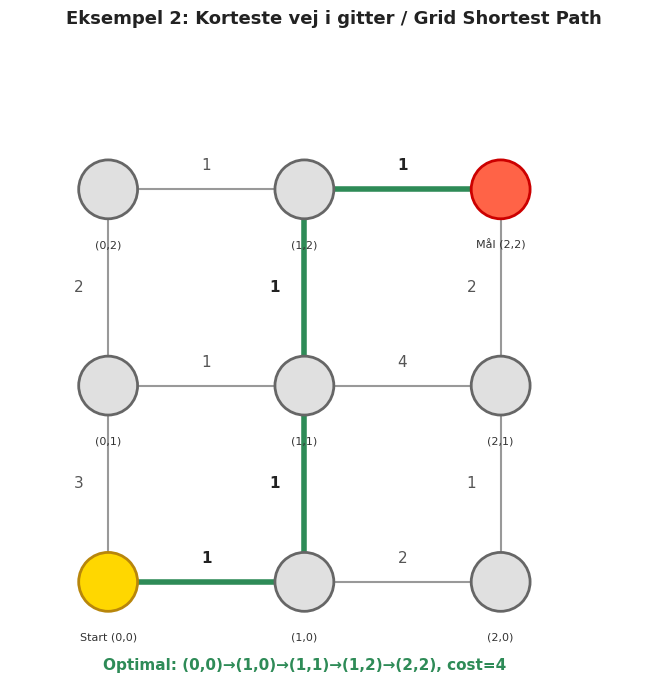

In [33]:
# Eksempel 2: Visuel graf / Visual graph — Grid shortest path
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(7, 7))
ax.set_xlim(-0.5, 2.8)
ax.set_ylim(-0.5, 2.8)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Eksempel 2: Korteste vej i gitter / Grid Shortest Path', fontsize=13, fontweight='bold', color='#222')

costs = {
    ((0,0),'right'): 1, ((0,0),'up'): 3,
    ((1,0),'right'): 2, ((1,0),'up'): 1,
    ((2,0),'up'):    1,
    ((0,1),'right'): 1, ((0,1),'up'): 2,
    ((1,1),'right'): 4, ((1,1),'up'): 1,
    ((2,1),'up'):    2,
    ((0,2),'right'): 1,
    ((1,2),'right'): 1,
}

opt_edges = {((0,0),'right'), ((1,0),'up'), ((1,1),'up'), ((1,2),'right')}

for (pos, direction), cost in costs.items():
    x, y = pos
    dx, dy = (1, 0) if direction == 'right' else (0, 1)
    is_opt = (pos, direction) in opt_edges
    color = '#2E8B57' if is_opt else '#999999'
    lw = 4 if is_opt else 1.5
    ax.plot([x, x+dx], [y, y+dy], color=color, lw=lw, zorder=1)
    mx, my = x + dx/2, y + dy/2
    offset = 0.12 if direction == 'right' else -0.15
    ax.text(mx + (0 if direction == 'right' else offset),
            my + (offset if direction == 'right' else 0),
            str(cost), fontsize=11, ha='center', va='center',
            fontweight='bold' if is_opt else 'normal',
            color='#222' if is_opt else '#555',
            bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor='none'))

for x in range(3):
    for y in range(3):
        if (x, y) == (0, 0):
            fc, ec = '#FFD700', '#B8860B'
            label = f'Start ({x},{y})'
        elif (x, y) == (2, 2):
            fc, ec = '#FF6347', '#CC0000'
            label = f'Mål ({x},{y})'
        else:
            fc, ec = '#E0E0E0', '#666666'
            label = f'({x},{y})'
        circle = plt.Circle((x, y), 0.15, facecolor=fc, edgecolor=ec, lw=2, zorder=5)
        ax.add_patch(circle)
        ax.text(x, y - 0.3, label, ha='center', fontsize=8, color='#333', zorder=6)

ax.text(1, -0.45, 'Optimal: (0,0)→(1,0)→(1,1)→(1,2)→(2,2), cost=4',
        ha='center', fontsize=11, fontweight='bold', color='#2E8B57')

plt.tight_layout()
plt.show()

In [44]:
# Eksempel 2: Korteste vej i gitter / Shortest path on grid (GPS navigation)

# Grid 3x3: positions (x, y) where x=col, y=row
# Edge costs represent fuel consumption (negative rewards)
# Each cell can go "right" (+1,0) or "up" (0,+1) if within bounds
# 
grid_costs = {
    # Row 0 (bottom)
    ((0,0), "right"): -1,  ((0,0), "up"): -3,
    ((1,0), "right"): -2,  ((1,0), "up"): -1,
    ((2,0), "up"):    -1,
    # Row 1 (middle)
    ((0,1), "right"): -1,  ((0,1), "up"): -2,
    ((1,1), "right"): -4,  ((1,1), "up"): -1,
    ((2,1), "up"):    -2,
    # Row 2 (top)
    ((0,2), "right"): -1,
    ((1,2), "right"): -1,
}

def next_state(s, a):
    x, y = s
    if a == "right": return (x + 1, y)
    if a == "up":    return (x, y + 1)

goal = (2, 2)
all_states = [(x, y) for x in range(3) for y in range(3)]

# DP backward: V[state] = max total reward (= min cost) to reach goal
V = {goal: 0}
policy = {}

# Process by increasing Manhattan distance from goal (closest first)
for dist in range(1, 5):
    for s in all_states:
        if s == goal:
            continue
        x, y = s
        if (2 - x) + (2 - y) != dist:
            continue
        best_val, best_act = float("-inf"), None
        for a in ["right", "up"]:
            ns = next_state(s, a)
            if ns[0] > 2 or ns[1] > 2:
                continue
            if (s, a) in grid_costs and ns in V:
                val = grid_costs[(s, a)] + V[ns]
                if val > best_val:
                    best_val, best_act = val, a
        if best_act is not None:
            V[s] = best_val
            policy[s] = best_act

# Print value function as grid
print("=== Værdifunktion V(s) — max total reward to goal ===")
for y in range(2, -1, -1):
    row = "  ".join(f"V{(x,y)}={V.get((x,y), '?'):>4}" for x in range(3))
    print(f"  {row}")

# Trace optimal path from (0,0)
print(f"\n=== Optimal rute / Optimal route ===")
s = (0, 0)
path_str = [str(s)]
total = 0
while s != goal:
    a = policy[s]
    r = grid_costs[(s, a)]
    total += r
    s = next_state(s, a)
    path_str.append(f"--{a}-->  {s}")
print(f"  {'  '.join(path_str)}")
print(f"  Total kostnad / Total cost = {-total} (belønning / reward = {total})")

=== Værdifunktion V(s) — max total reward to goal ===
  V(0, 2)=  -2  V(1, 2)=  -1  V(2, 2)=   0
  V(0, 1)=  -3  V(1, 1)=  -2  V(2, 1)=  -2
  V(0, 0)=  -4  V(1, 0)=  -3  V(2, 0)=  -3

=== Optimal rute / Optimal route ===
  (0, 0)  --right-->  (1, 0)  --up-->  (1, 1)  --up-->  (1, 2)  --right-->  (2, 2)
  Total kostnad / Total cost = 4 (belønning / reward = -4)


### ✅ Konklusion / Conclusion — Eksempel 2

**Resultater fra outputtet:**
- **Værdifunktionen** $V(s)$: den minimale totale kostnad fra hver celle til målet $(2,2)$. F.eks. $V(0,0) = -4$ betyder at den billigste rute fra start til mål koster 4.
- **Optimal rute:** $(0,0) \to (1,0) \to (1,1) \to (1,2) \to (2,2)$ med total kostnad = 4.

**DK:** Læg mærke til at den optimale rute undgår den dyre kant $(1,1) \to (2,1)$ der koster 4. I stedet går den op via $(1,1) \to (1,2)$ (kostnad 1) og derefter til højre $(1,2) \to (2,2)$ (kostnad 1). DP finder den **billigste** rute, ikke nødvendigvis den mest direkte.

**EN:** The optimal route avoids the expensive edge $(1,1) \to (2,1)$ costing 4. Instead it goes up via $(1,1) \to (1,2)$ (cost 1) then right $(1,2) \to (2,2)$ (cost 1). DP finds the **cheapest** route, not necessarily the most direct.

> **Real-world:** Præcis dette bruges i GPS-navigation — find den billigste/hurtigste rute baseret på kendte vejkostnader.

## Eksempel 3: Ressourceallokering over tid / Resource Allocation Over Time (Real-World: Budget Planning)

**Scenarie / Scenario:** En virksomhed har et budget på 4 enheder og skal fordele det over $T = 2$ perioder. I hver periode vælger de, hvor meget de investerer ($a_t$), og resten spares. Produktiviteten varierer per periode.

A company has a budget of 4 units and must allocate it over $T = 2$ periods. Each period they choose how much to invest ($a_t$), and the rest is saved. Productivity varies per period.

**Tilstand / State:** $s_t$ = resterende budget ved tid $t$.

**Handling / Action:** $a_t \in \{0, 1, \ldots, s_t\}$ = beløb investeret i periode $t$.

**Overgangsfunktion / Transition:** $s_{t+1} = s_t - a_t$ (resten spares)

**Belønning / Reward:**
- Periode 0: $r_0(s_0, a_0) = 3\sqrt{a_0}$ (høj produktivitet / high productivity)
- Periode 1: $r_1(s_1, a_1) = 2\sqrt{a_1}$ (lavere produktivitet / lower productivity)
- Terminal: $r_2(s_2) = s_2$ (restbudget har værdi / remaining budget has value)

### DP baglæns med $s_0 = 4$ / DP Backward with $s_0 = 4$

**Trin 1:** $V_2(s) = s$ for $s \in \{0, 1, 2, 3, 4\}$

**Trin 2:** $t = 1$, for hvert $s_1$:
$$V_1(s_1) = \max_{a_1 \in \{0,...,s_1\}} \Big\{ 2\sqrt{a_1} + V_2(s_1 - a_1) \Big\}$$

**Trin 3:** $t = 0$:
$$V_0(4) = \max_{a_0 \in \{0,...,4\}} \Big\{ 3\sqrt{a_0} + V_1(4 - a_0) \Big\}$$

**DK:** Skal vi investere alt i den høj-produktive periode? Eller spare noget? DP finder den optimale balance.

**EN:** Should we invest everything in the high-productivity period? Or save some? DP finds the optimal balance.

### 💰 Visuel oversigt / Visual Overview — Eksempel 3

```mermaid
graph LR
    S0["💰 Budget = 4"] -->|"invest a₀, r = 3√a₀"| S1["Budget = 4 − a₀"]
    S1 -->|"invest a₁, r = 2√a₁"| S2["Budget = 4 − a₀ − a₁"]
    S2 -->|"r = restbudget"| END["🏦 Terminal"]

    style S0 fill:#FFD700,stroke:#333,color:#333
    style END fill:#90EE90,stroke:#333,color:#333
```

```
  Optimal fordeling / allocation:
  ┌─────────────┬─────────────┬─────────────┐
  │  Periode 0  │  Periode 1  │  Terminal    │
  │  invest = 2 │  invest = 1 │  rest = 1   │
  │  r = 3√2    │  r = 2√1    │  r = 1      │
  │  = 4.24     │  = 2.00     │  = 1.00     │
  └─────────────┴─────────────┴─────────────┘
                       Total = 7.24
```

**Læsning:** Budget = 4 fordeles over 2 perioder. Periode 0 har høj produktivitet ($3\sqrt{a}$), periode 1 har lav ($2\sqrt{a}$). DP finder den optimale balance.

### LaTeX tidslinje / LaTeX Timeline

$$
\underset{s_0=4}{\fbox{Budget=4}}
\;\xrightarrow[\;r_0 = 3\sqrt{a_0}\;]{a_0 = 2}\;
\underset{s_1=2}{\fbox{Budget=2}}
\;\xrightarrow[\;r_1 = 2\sqrt{a_1}\;]{a_1 = 1}\;
\underset{s_2=1}{\fbox{Budget=1}}
\;\xrightarrow[\;r_T = s_2\;]{\text{terminal}}\;
\fbox{Slut}
$$

$$
V_0(4) = \underbrace{3\sqrt{2}}_{=4.24} + \underbrace{2\sqrt{1}}_{=2.00} + \underbrace{1}_{=1.00} = \mathbf{7.24}
$$

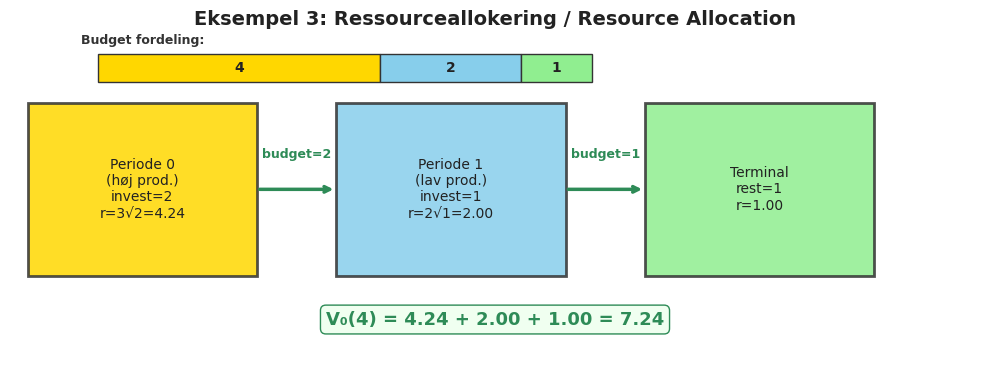

In [34]:
# Eksempel 3: Visuel graf / Visual graph — Resource allocation timeline
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(10, 4))
ax.set_xlim(-0.5, 10.5)
ax.set_ylim(-1.5, 3.5)
ax.axis('off')
ax.set_title('Eksempel 3: Ressourceallokering / Resource Allocation', fontsize=14, fontweight='bold', color='#222')

boxes = [
    (0.5, 'Periode 0\n(høj prod.)\ninvest=2\nr=3√2=4.24', '#FFD700'),
    (4, 'Periode 1\n(lav prod.)\ninvest=1\nr=2√1=2.00', '#87CEEB'),
    (7.5, 'Terminal\nrest=1\nr=1.00', '#90EE90'),
]

for x, text, color in boxes:
    rect = plt.Rectangle((x - 0.8, 0), 2.6, 2.5, facecolor=color, edgecolor='#333', lw=2,
                          alpha=0.85, zorder=3)
    ax.add_patch(rect)
    ax.text(x + 0.5, 1.25, text, ha='center', va='center', fontsize=10, color='#222', zorder=4)

for x1, x2, label in [(2.3, 3.2, 'budget=2'), (5.8, 6.7, 'budget=1')]:
    ax.annotate('', xy=(x2, 1.25), xytext=(x1, 1.25),
                arrowprops=dict(arrowstyle='->', lw=2.5, color='#2E8B57'))
    ax.text((x1+x2)/2, 1.7, label, ha='center', fontsize=9, color='#2E8B57', fontweight='bold')

# Budget bar on top
bar_data = [(4, '#FFD700'), (2, '#87CEEB'), (1, '#90EE90')]
for i, (b, c) in enumerate(bar_data):
    start = sum([4, 2, 1][:i])
    rect = plt.Rectangle((start * 0.8 + 0.5, 2.8), b * 0.8, 0.4, facecolor=c, edgecolor='#333', lw=1)
    ax.add_patch(rect)
    ax.text(start * 0.8 + 0.5 + b * 0.4, 3.0, str(b), ha='center', va='center',
            fontsize=10, fontweight='bold', color='#222')

ax.text(0.3, 3.35, 'Budget fordeling:', fontsize=9, fontweight='bold', color='#333')

ax.text(5, -0.7, 'V₀(4) = 4.24 + 2.00 + 1.00 = 7.24', ha='center', fontsize=13,
        fontweight='bold', color='#2E8B57',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#f0fff0', edgecolor='#2E8B57'))

plt.tight_layout()
plt.show()

In [45]:
# Eksempel 3: Ressourceallokering / Resource allocation (budget planning)
import math

budget = 4
T = 2

def reward(t, s, a):
    if t == 0: return 3 * math.sqrt(a)
    if t == 1: return 2 * math.sqrt(a)

def terminal_reward(s):
    return s  # remaining budget has value

# DP backward
V = [{} for _ in range(T + 1)]
policy = [{} for _ in range(T)]

# Step 1: terminal values
for s in range(budget + 1):
    V[T][s] = terminal_reward(s)

# Step 2: backward recursion
for t in range(T - 1, -1, -1):
    for s in range(budget + 1):
        best_val, best_act = float("-inf"), 0
        for a in range(s + 1):  # can invest 0 to s
            s_next = s - a
            val = reward(t, s, a) + V[t + 1][s_next]
            if val > best_val:
                best_val, best_act = val, a
        V[t][s] = best_val
        policy[t][s] = best_act

# Print value tables
for t in range(T + 1):
    print(f"V_{t}: " + "  ".join(f"V_{t}({s})={V[t][s]:.2f}" for s in range(budget + 1)))

print(f"\n=== Optimal politik / Optimal policy ===")
for t in range(T):
    for s in range(budget + 1):
        print(f"  π*_{t}(budget={s}) = invest {policy[t][s]}")

# Trace from s0 = 4
print(f"\n=== Optimal forløb / Optimal trajectory (s₀ = {budget}) ===")
s = budget
total = 0
for t in range(T):
    a = policy[t][s]
    r = reward(t, s, a)
    total += r
    print(f"  t={t}: budget={s}, invest={a}, reward={r:.2f}, remaining={s-a}")
    s = s - a
total += terminal_reward(s)
print(f"  t={T}: terminal budget={s}, terminal reward={terminal_reward(s):.2f}")
print(f"  Total reward = {total:.2f}")

V_0: V_0(0)=0.00  V_0(1)=3.00  V_0(2)=5.00  V_0(3)=6.24  V_0(4)=7.24
V_1: V_1(0)=0.00  V_1(1)=2.00  V_1(2)=3.00  V_1(3)=4.00  V_1(4)=5.00
V_2: V_2(0)=0.00  V_2(1)=1.00  V_2(2)=2.00  V_2(3)=3.00  V_2(4)=4.00

=== Optimal politik / Optimal policy ===
  π*_0(budget=0) = invest 0
  π*_0(budget=1) = invest 1
  π*_0(budget=2) = invest 1
  π*_0(budget=3) = invest 2
  π*_0(budget=4) = invest 2
  π*_1(budget=0) = invest 0
  π*_1(budget=1) = invest 1
  π*_1(budget=2) = invest 1
  π*_1(budget=3) = invest 1
  π*_1(budget=4) = invest 1

=== Optimal forløb / Optimal trajectory (s₀ = 4) ===
  t=0: budget=4, invest=2, reward=4.24, remaining=2
  t=1: budget=2, invest=1, reward=2.00, remaining=1
  t=2: terminal budget=1, terminal reward=1.00
  Total reward = 7.24


### ✅ Konklusion / Conclusion — Eksempel 3

**Resultater fra outputtet:**
- **Optimal strategi fra budget=4:** Invester 2 i periode 0, invester 1 i periode 1, behold 1 til sidst.
- **Total belønning:** $3\sqrt{2} + 2\sqrt{1} + 1 = 4.24 + 2.00 + 1.00 = 7.24$

**DK:** Selvom periode 0 har højere produktivitet ($3\sqrt{a}$ vs $2\sqrt{a}$), investerer den optimale politik **ikke** alt i periode 0. Aftagende marginal nytte (kvadratrodsfunktionen $\sqrt{a}$) betyder at de første enheder giver mest — så det betaler sig at sprede investeringen. At investere 4 i periode 0 giver $3\sqrt{4} = 6.0$, mens at sprede giver $3\sqrt{2} + 2\sqrt{1} + 1 = 7.24$.

**EN:** Even though period 0 has higher productivity, the optimal policy does **not** invest everything in period 0. Diminishing marginal returns (the square root $\sqrt{a}$) means the first units give the most — so it pays to spread investment.

> **Nøgleindsigt:** DP balancerer automatisk mellem udnyttelse nu og opsparing til fremtiden — det er kernen i ressourceallokering.

## Eksempel 4: Bellmans princip demonstreret / Bellman's Principle Demonstrated

**Scenarie / Scenario:** Vi viser, at halen af en optimal sti er optimal for haleproblemet. Betragt en 3-trins graf.

We demonstrate that the tail of an optimal path is optimal for the tail problem. Consider a 3-step graph.

**Graph:**

$s_0 = A$, handlinger "venstre" (L) og "højre" (R) i hvert trin.

| $t$ | Tilstand | L → (næste, bel.) | R → (næste, bel.) |
|-----|----------|--------------------|--------------------|
| 0 | A | B, 2 | C, 5 |
| 1 | B | D, 8 | E, 3 |
| 1 | C | E, 1 | F, 6 |
| 2 | D | G, 1 | H, 2 |
| 2 | E | H, 4 | I, 1 |
| 2 | F | I, 3 | J, 7 |

**Terminal:** $r_3 = 0$ for alle.

### Verifikation af Bellmans princip:

**Optimal sti:** A → R → C → R → F → R → J, total = $5 + 6 + 7 = 18$

**Hale fra C:** C → R → F → R → J, total = $6 + 7 = 13$. 

**Er dette optimalt for haleproblemet startende i C?** Alternativet er C → L → E → ? som giver max $1 + 4 = 5$. Ja, halen er optimal!

**DK:** Bellmans princip gælder: den optimale hale fra $C$ (vis $C \to F \to J$) er den bedste mulige fortsættelse fra $C$.

**EN:** Bellman's principle holds: the optimal tail from $C$ ($C \to F \to J$) is the best possible continuation from $C$.

### 🌳 Visuel oversigt / Visual Overview — Eksempel 4

```mermaid
graph TD
    A["🟡 A"] -->|"L, r=2"| B["B"]
    A -->|"R, r=5 ✅"| C["C"]
    B -->|"L, r=8"| D["D"]
    B -->|"R, r=3"| E1["E"]
    C -->|"L, r=1"| E2["E"]
    C -->|"R, r=6 ✅"| F["F"]
    D -->|"L, r=1"| G["G (0)"]
    D -->|"R, r=2"| H1["H (0)"]
    E1 -->|"L, r=4"| H2["H (0)"]
    E1 -->|"R, r=1"| I1["I (0)"]
    F -->|"L, r=3"| I2["I (0)"]
    F -->|"R, r=7 ✅"| J["J (0)"]

    style A fill:#FFD700,stroke:#333,color:#333
    style C fill:#90EE90,stroke:#333,color:#333
    style F fill:#90EE90,stroke:#333,color:#333
    style J fill:#90EE90,stroke:#333,color:#333
```

```
  Bellmans princip / Bellman's principle:
  ┌──────────────────────────────────────────────────┐
  │  Optimal sti: A → C → F → J  (total = 18)       │
  │                                                    │
  │  Hale fra C: C → F → J  (total = 13) ← OPTIMAL  │
  │  Alternativ:  C → E → H  (total = 5)  ← DÅRLIGERE│
  │                                                    │
  │  ✅ Halen af optimal sti ER optimal for           │
  │     haleproblemet!                                 │
  └──────────────────────────────────────────────────┘
```

### LaTeX beslutningstræ / LaTeX Decision Tree

$$
\begin{array}{ccccccccc}
& & & & \boxed{A} & & & & \\
& & \swarrow^{L,\;r=2} & & & & \searrow^{\mathbf{R,\;r=5}} & & \\
& \boxed{B} & & & & & & \boxed{\mathbf{C}} & \\
\swarrow^{L,\;8} & & \searrow^{R,\;3} & & & \swarrow^{L,\;1} & & \searrow^{\mathbf{R,\;6}} & \\
\boxed{D} & & \boxed{E} & & & \boxed{E} & & \boxed{\mathbf{F}} \\
{\scriptstyle L:1 \;\; R:2} & & {\scriptstyle L:4 \;\; R:1} & & & {\scriptstyle L:4 \;\; R:1} & & {\scriptstyle L:3 \;\;\; \mathbf{R:7}} \\
\end{array}
$$

$$
\underbrace{A \xrightarrow{5} C \xrightarrow{6} F \xrightarrow{7} J}_{\text{optimal sti, total} = 18}
\qquad
\underbrace{C \xrightarrow{6} F \xrightarrow{7} J}_{\text{hale fra } C = 13}
\;\; > \;\;
\underbrace{C \xrightarrow{1} E \xrightarrow{4} H}_{\text{alternativ} = 5}
$$

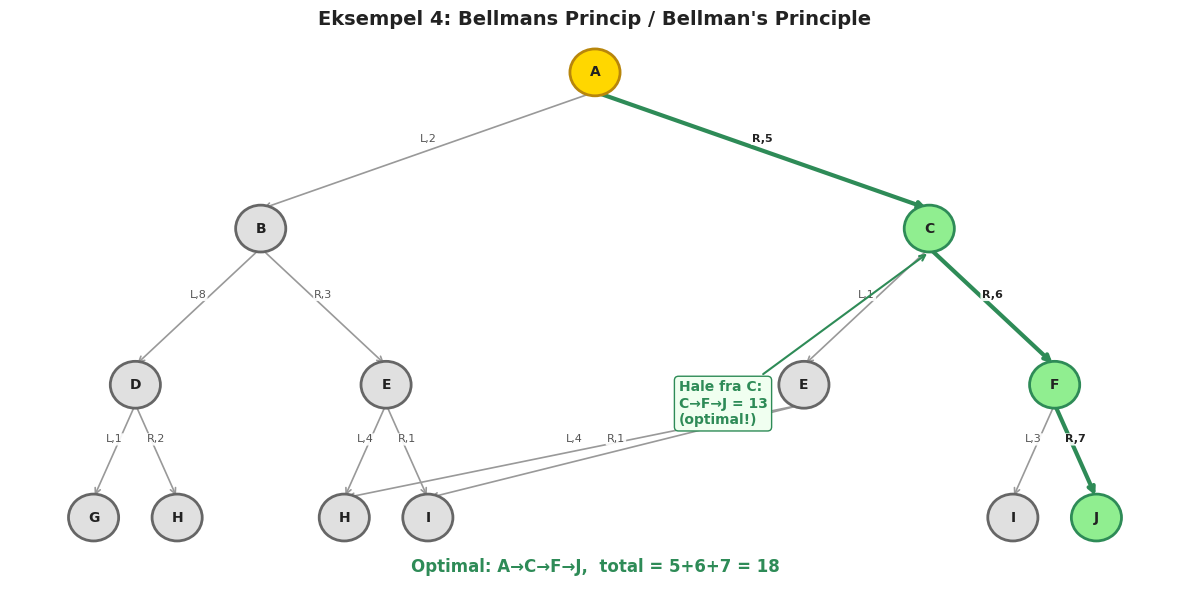

In [35]:
# Eksempel 4: Visuel graf / Visual graph — Bellman's principle (3-step tree)
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(12, 6))
ax.set_xlim(-1, 13)
ax.set_ylim(-0.5, 6.5)
ax.axis('off')
ax.set_title("Eksempel 4: Bellmans Princip / Bellman's Principle", fontsize=14, fontweight='bold', color='#222')

pos = {
    'A': (6, 6),
    'B': (2, 4), 'C': (10, 4),
    'D': (0.5, 2), 'E_B': (3.5, 2), 'E_C': (8.5, 2), 'F': (11.5, 2),
    'G': (0, 0.3), 'H_D': (1, 0.3), 'H_E': (3, 0.3), 'I_E': (4, 0.3),
    'I_F': (11, 0.3), 'J': (12, 0.3)
}

edges = [
    ('A','B','L,2',False), ('A','C','R,5',True),
    ('B','D','L,8',False), ('B','E_B','R,3',False),
    ('C','E_C','L,1',False), ('C','F','R,6',True),
    ('D','G','L,1',False), ('D','H_D','R,2',False),
    ('E_B','H_E','L,4',False), ('E_B','I_E','R,1',False),
    ('E_C','H_E','L,4',False), ('E_C','I_E','R,1',False),
    ('F','I_F','L,3',False), ('F','J','R,7',True),
]

for src, dst, label, opt in edges:
    x0, y0 = pos[src]; x1, y1 = pos[dst]
    color = '#2E8B57' if opt else '#999999'
    lw = 3 if opt else 1.2
    ax.annotate('', xy=(x1, y1+0.25), xytext=(x0, y0-0.25),
                arrowprops=dict(arrowstyle='->', color=color, lw=lw))
    mx, my = (x0+x1)/2, (y0+y1)/2
    ax.text(mx, my+0.15, label, fontsize=8, ha='center', va='center',
            color='#222' if opt else '#555', fontweight='bold' if opt else 'normal',
            bbox=dict(boxstyle='round,pad=0.1', facecolor='white', edgecolor='none', alpha=0.9))

for name, (x, y) in pos.items():
    display = name.split('_')[0]
    if name == 'A':
        fc, ec = '#FFD700', '#B8860B'
    elif name in ('C', 'F', 'J'):
        fc, ec = '#90EE90', '#2E8B57'
    else:
        fc, ec = '#E0E0E0', '#666666'
    circle = plt.Circle((x, y), 0.3, facecolor=fc, edgecolor=ec, lw=2, zorder=5)
    ax.add_patch(circle)
    ax.text(x, y, display, ha='center', va='center', fontsize=10, fontweight='bold', color='#222', zorder=6)

ax.annotate('Hale fra C:\nC→F→J = 13\n(optimal!)',
            xy=(10, 3.7), xytext=(7, 1.5),
            fontsize=10, color='#2E8B57', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#2E8B57', lw=1.5),
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#f0fff0', edgecolor='#2E8B57'))

ax.text(6, -0.4, 'Optimal: A→C→F→J,  total = 5+6+7 = 18', ha='center',
        fontsize=12, fontweight='bold', color='#2E8B57')

plt.tight_layout()
plt.show()

In [46]:
# Eksempel 4: Bellmans princip / Bellman's principle of optimality

transitions = {
    (0, "A", "L"): ("B", 2), (0, "A", "R"): ("C", 5),
    (1, "B", "L"): ("D", 8), (1, "B", "R"): ("E", 3),
    (1, "C", "L"): ("E", 1), (1, "C", "R"): ("F", 6),
    (2, "D", "L"): ("G", 1), (2, "D", "R"): ("H", 2),
    (2, "E", "L"): ("H", 4), (2, "E", "R"): ("I", 1),
    (2, "F", "L"): ("I", 3), (2, "F", "R"): ("J", 7),
}

stages = {0: ["A"], 1: ["B", "C"], 2: ["D", "E", "F"], 3: ["G", "H", "I", "J"]}
T = 3

# DP backward
V = {s: 0 for s in stages[T]}
policy = {}

for t in range(T - 1, -1, -1):
    for s in stages[t]:
        best_val, best_act = float("-inf"), None
        for a in ["L", "R"]:
            if (t, s, a) in transitions:
                s_next, r = transitions[(t, s, a)]
                val = r + V[s_next]
                if val > best_val:
                    best_val, best_act = val, a
        V[s] = best_val
        policy[(t, s)] = best_act

# Trace full optimal path
print("=== Fuld optimal sti / Full optimal path ===")
s, total = "A", 0
path = [s]
for t in range(T):
    a = policy[(t, s)]
    s_next, r = transitions[(t, s, a)]
    total += r
    path.append(f"--{a}({r})-->  {s_next}")
    s = s_next
print(f"  {'  '.join(path)}")
print(f"  Total = {total}")

# Verify Bellman's principle: tail from C
print(f"\n=== Bellmans princip: hale fra C / Tail from C ===")
print(f"  V(C) = {V['C']}  (bedste mulige fra C / best possible from C)")
s, total = "C", 0
path = ["C"]
for t in range(1, T):
    a = policy[(t, s)]
    s_next, r = transitions[(t, s, a)]
    total += r
    path.append(f"--{a}({r})-->  {s_next}")
    s = s_next
print(f"  Optimal hale: {'  '.join(path)}, reward = {total}")

# Check alternative from C
alt_r = transitions[(1, "C", "L")][1] + max(
    transitions[(2, "E", "L")][1], transitions[(2, "E", "R")][1]
)
print(f"  Alternativ C->L->E->best = {alt_r}")
print(f"  ✓ Halen er optimal / Tail is optimal: {total} > {alt_r}")

=== Fuld optimal sti / Full optimal path ===
  A  --R(5)-->  C  --R(6)-->  F  --R(7)-->  J
  Total = 18

=== Bellmans princip: hale fra C / Tail from C ===
  V(C) = 13  (bedste mulige fra C / best possible from C)
  Optimal hale: C  --R(6)-->  F  --R(7)-->  J, reward = 13
  Alternativ C->L->E->best = 5
  ✓ Halen er optimal / Tail is optimal: 13 > 5


### ✅ Konklusion / Conclusion — Eksempel 4

**Resultater fra outputtet:**
- **Fuld optimal sti:** $A \to C \to F \to J$ med total belønning $= 5 + 6 + 7 = 18$
- **Halen fra C:** $C \to F \to J$ med belønning $= 6 + 7 = 13$
- **Alternativ fra C:** $C \to E \to H = 1 + 4 = 5$ — langt dårligere!

**DK — Bellmans princip verificeret:** Halen af den optimale sti ($C \to F \to J = 13$) er bedre end enhver alternativ fortsættelse fra $C$ (bedste alternativ = 5). Halen er optimal for haleproblemet — præcis som Bellmans princip lover.

**EN — Bellman's principle verified:** The tail of the optimal path ($C \to F \to J = 13$) outperforms any alternative continuation from $C$ (best alternative = 5). The tail is optimal for the tail problem — exactly as Bellman's principle promises.

> **Hvorfor er dette vigtigt?** Det er grundlaget for hele DP: Hvis halen **altid** er optimal, kan vi bygge den samlede løsning op ét trin ad gangen, startende fra slutningen. Uden dette princip ville DP ikke virke!

## Eksempel 5: Politik vs. sti / Policy vs. Path

**Scenarie / Scenario:** Vi viser forskellen: en **sti** angiver kun handlinger for besøgte tilstande; en **politik** angiver en handling for *alle* tilstande.

We demonstrate the difference: a **path** specifies actions only for visited states; a **policy** specifies an action for *all* states.

**System:** $T = 1$, $\mathcal{S}_0 = \{X, Y\}$, $\mathcal{S}_1 = \{P, Q, R\}$

| Overgang | Belønning |
|----------|-----------|
| $f(X, a) = P$ | $r = 5$ |
| $f(X, b) = Q$ | $r = 3$ |
| $f(Y, a) = Q$ | $r = 4$ |
| $f(Y, b) = R$ | $r = 8$ |

### Sti vs. politik

**Sti fra $X$:** $(X, a, P)$ — siger intet om hvad vi gør i $Y$.

**Politik:** $\pi(X) = a$, $\pi(Y) = b$ — specificerer en handling for *alle* tilstande i $\mathcal{S}_0$.

**DK:** En politik er mere generel end en sti. Politikken kan håndtere enhver starttilstand. Stien virker kun fra den specifikke start.

**EN:** A policy is more general than a path. The policy can handle any starting state. The path only works from its specific start.

### Induceret sti / Induced path

Politikken $\pi$ inducerer følgende stier:
- Fra $X$: $(X, a, P)$ med belønning $5$  
- Fra $Y$: $(Y, b, R)$ med belønning $8$

### 🔀 Visuel oversigt / Visual Overview — Eksempel 5

```
  ┌─────────────────────────────────────────────────────────┐
  │           STI / PATH (fra X)    POLITIK / POLICY        │
  │         ──────────────────────  ──────────────────────  │
  │                                                         │
  │         X ──a──→ P  (r=5)      X ──a──→ P  (r=5)     │
  │                                 Y ──b──→ R  (r=8)     │
  │                                                         │
  │         Siger intet om Y! ❌    Dækker ALLE tilstande ✅│
  └─────────────────────────────────────────────────────────┘
```

```mermaid
graph LR
    subgraph "Politik / Policy (dækker alle)"
        X2["X"] -->|"a, r=5 ✅"| P2["P"]
        X2 -->|"b, r=3"| Q2["Q"]
        Y2["Y"] -->|"a, r=4"| Q3["Q"]
        Y2 -->|"b, r=8 ✅"| R2["R"]
    end
```

**Læsning:** En sti er EN rejse fra ét punkt. En politik er en komplet handlingsplan for ALLE tilstande. DP giver altid en politik.

### LaTeX graf / LaTeX Graph

**Sti / Path** (kun fra $X$):

$$
X \xrightarrow{\;a,\; r=5\;} P \qquad \text{(siger intet om } Y \text{!)}
$$

**Politik / Policy** (for alle $s \in \mathcal{S}_0$):

$$
\begin{cases}
\pi^*(X) = a: & X \xrightarrow{\;a,\; r=5\;} P \\[6pt]
\pi^*(Y) = b: & Y \xrightarrow{\;b,\; r=8\;} R
\end{cases}
$$

$$
\text{Alle overgange / All transitions:}\quad
\begin{array}{c|cc}
 & a & b \\ \hline
X & P,\;\mathbf{r=5} & Q,\;r=3 \\
Y & Q,\;r=4 & R,\;\mathbf{r=8}
\end{array}
$$

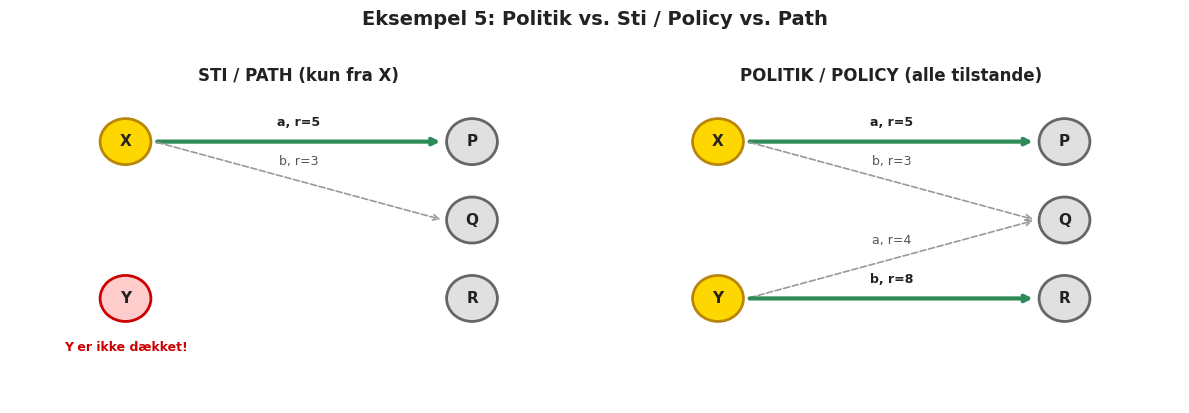

In [36]:
# Eksempel 5: Visuel graf / Visual graph — Policy vs Path
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

def draw_policy_graph(ax, title, show_all=False):
    ax.set_xlim(-0.5, 4.5)
    ax.set_ylim(-0.5, 2.5)
    ax.axis('off')
    ax.set_title(title, fontsize=12, fontweight='bold', color='#222')

    nodes = {'X': (0.5, 2), 'Y': (0.5, 0.5), 'P': (3.5, 2), 'Q': (3.5, 1.25), 'R': (3.5, 0.5)}

    if show_all:
        edge_list = [
            ('X', 'P', 'a, r=5', True), ('X', 'Q', 'b, r=3', False),
            ('Y', 'Q', 'a, r=4', False), ('Y', 'R', 'b, r=8', True),
        ]
    else:
        edge_list = [
            ('X', 'P', 'a, r=5', True), ('X', 'Q', 'b, r=3', False),
        ]

    for src, dst, label, opt in edge_list:
        x0, y0 = nodes[src]; x1, y1 = nodes[dst]
        color = '#2E8B57' if opt else '#999999'
        lw = 3 if opt else 1.2
        ax.annotate('', xy=(x1-0.25, y1), xytext=(x0+0.25, y0),
                    arrowprops=dict(arrowstyle='->', color=color, lw=lw,
                                    linestyle='-' if opt else '--'))
        mx, my = (x0+x1)/2, (y0+y1)/2
        ax.text(mx, my+0.15, label, fontsize=9, ha='center',
                color='#222' if opt else '#555', fontweight='bold' if opt else 'normal')

    for name, (x, y) in nodes.items():
        if name in ('X', 'Y') and not show_all and name == 'Y':
            fc, ec = '#FFCCCC', '#CC0000'
        elif name in ('X', 'Y'):
            fc, ec = '#FFD700', '#B8860B'
        else:
            fc, ec = '#E0E0E0', '#666666'
        circle = plt.Circle((x, y), 0.22, facecolor=fc, edgecolor=ec, lw=2, zorder=5)
        ax.add_patch(circle)
        ax.text(x, y, name, ha='center', va='center', fontsize=11, fontweight='bold', color='#222', zorder=6)

    if not show_all:
        ax.text(0.5, 0.0, 'Y er ikke dækket!', ha='center', fontsize=9, color='#CC0000', fontweight='bold')

draw_policy_graph(ax1, 'STI / PATH (kun fra X)', show_all=False)
draw_policy_graph(ax2, 'POLITIK / POLICY (alle tilstande)', show_all=True)

fig.suptitle('Eksempel 5: Politik vs. Sti / Policy vs. Path', fontsize=14, fontweight='bold', color='#222', y=1.02)
plt.tight_layout()
plt.show()

In [47]:
# Eksempel 5: Politik vs. sti / Policy vs. path

transitions = {
    ("X", "a"): ("P", 5), ("X", "b"): ("Q", 3),
    ("Y", "a"): ("Q", 4), ("Y", "b"): ("R", 8),
}

# A PATH from X: only specifies what to do at X
path_from_X = [("X", "a")]  # says nothing about Y

# A POLICY: specifies action for ALL states
policy = {"X": "a", "Y": "b"}

print("=== Sti / Path (fra X) ===")
s, a = path_from_X[0]
s_next, r = transitions[(s, a)]
print(f"  ({s}, {a}) → {s_next}, reward = {r}")
print(f"  Stien siger intet om Y / Path says nothing about Y\n")

print("=== Politik / Policy (for alle tilstande) ===")
for s0 in ["X", "Y"]:
    a = policy[s0]
    s_next, r = transitions[(s0, a)]
    print(f"  π({s0}) = {a}  →  induceret sti: ({s0}, {a}, {s_next}), reward = {r}")

# DP finds the optimal POLICY (not just a path)
print("\n=== Optimal politik via DP / Optimal policy via DP ===")
optimal_policy = {}
for s0 in ["X", "Y"]:
    best_val, best_act = float("-inf"), None
    for a in ["a", "b"]:
        s_next, r = transitions[(s0, a)]
        if r > best_val:
            best_val, best_act = r, a
    optimal_policy[s0] = best_act
    print(f"  π*({s0}) = {best_act} (reward = {best_val})")

=== Sti / Path (fra X) ===
  (X, a) → P, reward = 5
  Stien siger intet om Y / Path says nothing about Y

=== Politik / Policy (for alle tilstande) ===
  π(X) = a  →  induceret sti: (X, a, P), reward = 5
  π(Y) = b  →  induceret sti: (Y, b, R), reward = 8

=== Optimal politik via DP / Optimal policy via DP ===
  π*(X) = a (reward = 5)
  π*(Y) = b (reward = 8)


### ✅ Konklusion / Conclusion — Eksempel 5

**Resultater fra outputtet:**
- **Sti fra X:** $(X, a, P)$ med reward = 5. Stien siger **intet** om hvad der sker fra $Y$.
- **Politik:** $\pi(X) = a, \; \pi(Y) = b$ — dækker **begge** starttilstande.
- **Optimal politik via DP:** $\pi^*(X) = a$ (reward 5), $\pi^*(Y) = b$ (reward 8).

**DK:** En **sti** er en enkelt rejse fra et specifikt startpunkt — den er "næsten ubrugelig", fordi den kun virker for den ene start. En **politik** er en komplet handlingsplan der dækker alle tilstande. DP producerer altid en politik, og politikken inducerer automatisk den optimale sti fra **enhver** starttilstand.

**EN:** A **path** is a single journey from one starting point — it's limited because it only works for that one start. A **policy** is a complete action plan covering all states. DP always produces a policy, which automatically induces the optimal path from **any** starting state.

> **Nøgleindsigt:** I RL søger vi altid efter **politikker**, ikke stier. Politikken er den generelle løsning.

## Eksempel 6: Lagerstyring / Inventory Management (Real-World: Supermarked)

**Scenarie / Scenario:** Et supermarked skal beslutteordrer over $T = 3$ dage. For mange varer koster lagerplads; for få varer koster tabte salg.

A supermarket must decide orders over $T = 3$ days. Too many items costs storage; too few costs lost sales.

**Tilstand / State:** $s_t$ = antal varer på lager (kapacitet max 4)

**Handling / Action:** $a_t \in \{0, 1, 2\}$ = antal varer bestilt

**Overgangsfunktion / Transition:** $s_{t+1} = \min(s_t + a_t, 4) - d_t$ hvor $d_t$ er efterspørgslen (deterministisk: $d_0 = 2, d_1 = 1, d_2 = 3$). Tilstand kan ikke gå under 0.

$$s_{t+1} = \max\Big(\min(s_t + a_t, 4) - d_t, \; 0\Big)$$

**Belønning / Reward:** 
$$r_t(s_t, a_t) = \underbrace{10 \cdot \min(s_t + a_t, d_t)}_{\text{salgsindtægt / sales revenue}} - \underbrace{3 \cdot a_t}_{\text{ordrekostnad / order cost}} - \underbrace{1 \cdot \max(s_t + a_t - d_t, 0)}_{\text{lagerkostnad / storage cost}}$$

Terminal: $r_3(s_3) = 0$

**DK:** Klassisk operations research — DP er standarden!

**EN:** Classic operations research — DP is the standard approach!

### 🏪 Visuel oversigt / Visual Overview — Eksempel 6

```
  Dag/Day 0 (d₀=2)      Dag/Day 1 (d₁=1)      Dag/Day 2 (d₂=3)
  ┌────────────────┐    ┌────────────────┐    ┌────────────────┐
  │ 📦 lager: s₀   │    │ 📦 lager: s₁   │    │ 📦 lager: s₂   │
  │ 🛒 bestil: a₀  │──→ │ 🛒 bestil: a₁  │──→ │ 🛒 bestil: a₂  │──→ s₃
  │ 🛍️ sælg: d₀=2  │    │ 🛍️ sælg: d₁=1  │    │ 🛍️ sælg: d₂=3  │
  └────────────────┘    └────────────────┘    └────────────────┘

  Belønning per dag / Reward per day:
  ┌─────────────────────────────────────────────────────┐
  │  r = 10·solgt − 3·bestilt − 1·overskud_på_lager    │
  │      ↑ salg      ↑ ordrekost   ↑ lagerkost          │
  └─────────────────────────────────────────────────────┘


  Overgang / Transition:
  s_{t+1} = max(min(s_t + a_t, 4) − d_t, 0)
            ↑ kan ikke gå under 0
                  ↑ max kapacitet = 4
```

### LaTeX tidslinje / LaTeX Timeline

$$
\underset{s_0}{\fbox{Lager}}
\;\xrightarrow[\substack{d_0=2 \\ r_0 = 10\min(s_0+a_0,d_0)-3a_0-1\cdot\text{overskud}}]{a_0 \in \{0,1,2\}}\;
\underset{s_1}{\fbox{Lager}}
\;\xrightarrow[\substack{d_1=1}]{a_1}\;
\underset{s_2}{\fbox{Lager}}
\;\xrightarrow[\substack{d_2=3}]{a_2}\;
\underset{s_3}{\fbox{Slut}}
$$

**Overgang / Transition:**

$$
s_{t+1} = \max\Big(\underbrace{\min(s_t + a_t, 4)}_{\text{fyldt lager (max 4)}} - \underbrace{d_t}_{\text{efterspørgsel}},\;\; 0\Big)
$$

**Belønning / Reward:**

$$
r_t(s_t, a_t) = \underbrace{10 \cdot \min(s_t + a_t,\; d_t)}_{\text{salgsindtægt}} - \underbrace{3 \cdot a_t}_{\text{ordrekost}} - \underbrace{1 \cdot \max(s_t + a_t - d_t,\; 0)}_{\text{lagerkost}}
$$

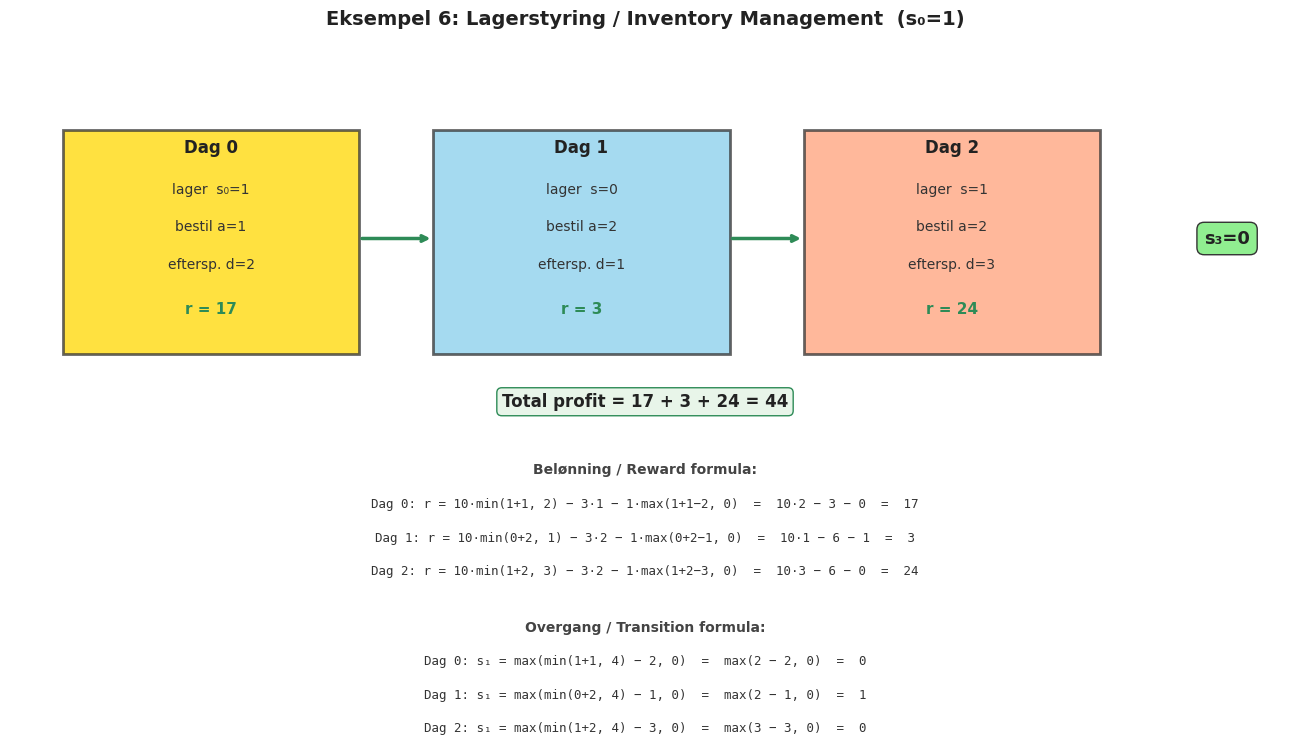

In [59]:
# Eksempel 6: Visuel graf / Visual graph — Inventory management swim lane
import matplotlib.pyplot as plt
import numpy as np

# ---- Compute optimal policy + simulation (same logic as implementation) ----
T_vis = 3
max_stock_vis = 4
max_order_vis = 2
demand_vis = {0: 2, 1: 1, 2: 3}

def trans_vis(s, a, t):
    return max(min(s + a, max_stock_vis) - demand_vis[t], 0)

def rew_vis(s, a, t):
    stock_after = min(s + a, max_stock_vis)
    sold = min(stock_after, demand_vis[t])
    left = max(stock_after - demand_vis[t], 0)
    return 10 * sold - 3 * a - 1 * left

V_vis = [{} for _ in range(T_vis + 1)]
pol_vis = [{} for _ in range(T_vis)]
for s in range(max_stock_vis + 1):
    V_vis[T_vis][s] = 0
for t in range(T_vis - 1, -1, -1):
    for s in range(max_stock_vis + 1):
        best_v, best_a = float("-inf"), 0
        for a in range(max_order_vis + 1):
            v = rew_vis(s, a, t) + V_vis[t + 1][trans_vis(s, a, t)]
            if v > best_v:
                best_v, best_a = v, a
        V_vis[t][s] = best_v
        pol_vis[t][s] = best_a

s0_vis = 1
sim = []
s = s0_vis
for t in range(T_vis):
    a = pol_vis[t][s]
    r = rew_vis(s, a, t)
    s_next = trans_vis(s, a, t)
    sim.append((s, a, demand_vis[t], r, s_next))
    s = s_next
total_profit = sum(x[3] for x in sim)

# ---- Plot ----
fig, ax = plt.subplots(1, 1, figsize=(13, 7.5))
ax.set_xlim(-0.5, 11.5)
ax.set_ylim(-3.8, 4.5)
ax.axis('off')
ax.set_title(f'Eksempel 6: Lagerstyring / Inventory Management  (s\u2080={s0_vis})',
             fontsize=14, fontweight='bold', color='#222')

box_colors = ['#FFD700', '#87CEEB', '#FFA07A']

for i, (st, at, dt, rt, sn) in enumerate(sim):
    x = i * 3.5 + 0.3
    # Box
    rect = plt.Rectangle((x - 0.3, 0.2), 2.8, 3.0, facecolor=box_colors[i],
                          edgecolor='#333', lw=2, alpha=0.75, zorder=2)
    ax.add_patch(rect)
    ax.text(x + 1.1, 2.9, f'Dag {i}', ha='center', fontsize=12, fontweight='bold', color='#222')
    ax.text(x + 1.1, 2.35, f'lager  s\u2080={st}' if i == 0 else f'lager  s={st}',
            ha='center', fontsize=10, color='#333')
    ax.text(x + 1.1, 1.85, f'bestil a={at}', ha='center', fontsize=10, color='#333')
    ax.text(x + 1.1, 1.35, f'eftersp. d={dt}', ha='center', fontsize=10, color='#333')
    ax.text(x + 1.1, 0.75, f'r = {rt}', ha='center', fontsize=11, fontweight='bold',
            color='#2E8B57')
    # Arrow to next
    if i < T_vis - 1:
        ax.annotate('', xy=(x + 3.2, 1.75), xytext=(x + 2.5, 1.75),
                    arrowprops=dict(arrowstyle='->', lw=2.5, color='#2E8B57'))

# Terminal state box
ax.text(11.0, 1.75, f's\u2083={sim[-1][4]}', ha='center', va='center', fontsize=13,
        fontweight='bold', color='#222',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#90EE90', edgecolor='#333'))

# Total
ax.text(5.5, -0.5, f'Total profit = {" + ".join(str(x[3]) for x in sim)} = {total_profit}',
        ha='center', fontsize=12, fontweight='bold', color='#222',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#E8F5E9', edgecolor='#2E8B57'))

# --- Formulas with numbers plugged in ---
y_form = -1.4
ax.text(5.5, y_form, 'Belønning / Reward formula:', ha='center', fontsize=10,
        fontweight='bold', color='#444')

for i, (st, at, dt, rt, sn) in enumerate(sim):
    stock_after = min(st + at, max_stock_vis)
    sold = min(stock_after, dt)
    left = max(stock_after - dt, 0)
    line = (f'Dag {i}: r = 10·min({st}+{at}, {dt}) − 3·{at} − 1·max({st}+{at}−{dt}, 0)'
            f'  =  10·{sold} − {3*at} − {left}  =  {rt}')
    ax.text(5.5, y_form - 0.45 * (i + 1), line, ha='center', fontsize=9,
            fontfamily='monospace', color='#333')

y_trans = y_form - 0.45 * (T_vis + 1) - 0.3
ax.text(5.5, y_trans, 'Overgang / Transition formula:', ha='center', fontsize=10,
        fontweight='bold', color='#444')

for i, (st, at, dt, rt, sn) in enumerate(sim):
    cap = min(st + at, max_stock_vis)
    line = (f'Dag {i}: s\u2081 = max(min({st}+{at}, 4) − {dt}, 0)'
            f'  =  max({cap} − {dt}, 0)  =  {sn}')
    ax.text(5.5, y_trans - 0.45 * (i + 1), line, ha='center', fontsize=9,
            fontfamily='monospace', color='#333')

plt.tight_layout()
plt.show()

In [58]:
# Eksempel 6: Lagerstyring / Inventory management (supermarket)

T = 3
max_stock = 4
max_order = 2
demand = {0: 2, 1: 1, 2: 3}  # deterministic daily demand

def transition(s, a, t):
    return max(min(s + a, max_stock) - demand[t], 0)

def reward(s, a, t):
    stock_after_order = min(s + a, max_stock)
    sold = min(stock_after_order, demand[t])
    leftover = max(stock_after_order - demand[t], 0)
    return 10 * sold - 3 * a - 1 * leftover

# DP backward
V = [{} for _ in range(T + 1)]
policy = [{} for _ in range(T)]

for s in range(max_stock + 1):
    V[T][s] = 0

for t in range(T - 1, -1, -1):
    for s in range(max_stock + 1):
        best_val, best_act = float("-inf"), 0
        for a in range(max_order + 1):
            s_next = transition(s, a, t)
            val = reward(s, a, t) + V[t + 1][s_next]
            if val > best_val:
                best_val, best_act = val, a
        V[t][s] = best_val
        policy[t][s] = best_act

print("=== Værdifunktioner / Value functions ===")
for t in range(T + 1):
    vals = "  ".join(f"V_{t}(stock={s})={V[t][s]:>5.0f}" for s in range(max_stock + 1))
    print(f"  {vals}")

print(f"\n=== Optimal politik / Optimal policy ===")
for t in range(T):
    acts = "  ".join(f"π_{t}(stock={s})=order {policy[t][s]}" for s in range(max_stock + 1))
    print(f"  {acts}")

# Simulate from s0 = 1
s0 = 1
print(f"\n=== Simulation: start med {s0} varer / start with {s0} items ===")
s = s0
total = 0
for t in range(T):
    a = policy[t][s]
    r = reward(s, a, t)
    s_next = transition(s, a, t)
    total += r
    print(f"  Dag {t}: lager={s}, bestil={a}, efterspørgsel={demand[t]}, reward={r}, nyt lager={s_next}")
    s = s_next
print(f"  Total profit = {total}")

=== Værdifunktioner / Value functions ===
  V_0(stock=0)=   41  V_0(stock=1)=   44  V_0(stock=2)=   47  V_0(stock=3)=   49  V_0(stock=4)=   51
  V_1(stock=0)=   27  V_1(stock=1)=   30  V_1(stock=2)=   33  V_1(stock=3)=   35  V_1(stock=4)=   37
  V_2(stock=0)=   14  V_2(stock=1)=   24  V_2(stock=2)=   27  V_2(stock=3)=   30  V_2(stock=4)=   29
  V_3(stock=0)=    0  V_3(stock=1)=    0  V_3(stock=2)=    0  V_3(stock=3)=    0  V_3(stock=4)=    0

=== Optimal politik / Optimal policy ===
  π_0(stock=0)=order 2  π_0(stock=1)=order 1  π_0(stock=2)=order 0  π_0(stock=3)=order 0  π_0(stock=4)=order 0
  π_1(stock=0)=order 2  π_1(stock=1)=order 1  π_1(stock=2)=order 0  π_1(stock=3)=order 0  π_1(stock=4)=order 0
  π_2(stock=0)=order 2  π_2(stock=1)=order 2  π_2(stock=2)=order 1  π_2(stock=3)=order 0  π_2(stock=4)=order 0

=== Simulation: start med 1 varer / start with 1 items ===
  Dag 0: lager=1, bestil=1, efterspørgsel=2, reward=17, nyt lager=0
  Dag 1: lager=0, bestil=2, efterspørgsel=1, reward

### ✅ Konklusion / Conclusion — Eksempel 6

**Resultater fra outputtet** (simulation fra start-lager = 1):
- Politikken varierer per dag og lagerniveau — f.eks. bestil mere når lageret er lavt og efterspørgslen er høj.
- DP afvejer de tre modsatrettede mål: sælg mest muligt, undgå høje ordrekostnader, og hold lageret lavt.

**DK:** DP håndterer automatisk trade-off'en: bestil nok til at dække efterspørgslen (undgå tabte salg = $10 \times$ mistet), men ikke for meget (undgå lagerkostnad = $1 \times$ overskud). Politikken afhænger af *både* nuværende lager *og* hvornår vi er, fordi fremtidig efterspørgsel varierer ($d_0=2, d_1=1, d_2=3$).

**EN:** DP automatically handles the trade-off: order enough to cover demand (avoid lost sales = $10 \times$ missed), but not too much (avoid storage costs = $1 \times$ excess). The policy depends on *both* current inventory *and* when we are, since future demand varies.

> **Real-world:** Præcis dette bruges i virkelige lagerstyringssystemer hos supermarkeder, Amazon og alle virksomheder med fysiske lagre. Den deterministiske version er den simpleste — i praksis er efterspørgslen stokastisk (MDP).

## Eksempel 7: Tidsvarierende system / Time-Varying System

**Scenarie / Scenario:** Vi viser et system hvor overgangs- og belønningsfunktionerne **ændrer sig over tid** ($f_t$ afhænger af $t$).

We show a system where transition and reward functions **change over time** ($f_t$ depends on $t$).

**Real-world:** En landmand dyrker afgrøder over 3 sæsoner. I forår (t=0) giver gødning dobbelt effekt; om sommeren (t=1) giver vanding mest; om efteråret (t=2) handler det om høst.

A farmer grows crops over 3 seasons. In spring (t=0) fertilizer has double effect; in summer (t=1) watering gives most; in autumn (t=2) it's about harvesting.

**Tilstand / State:** $s_t$ = afgrødeniveau $\in \{0, 1, 2, 3\}$

**Handling / Action:** $a_t \in \{\text{nothing}, \text{invest}\}$

**Overgang (tidsvarierende) / Transition (time-varying):**
- $t = 0$ (forår): $f_0(s, \text{invest}) = \min(s + 2, 3)$, $f_0(s, \text{nothing}) = s$
- $t = 1$ (sommer): $f_1(s, \text{invest}) = \min(s + 1, 3)$, $f_1(s, \text{nothing}) = \max(s - 1, 0)$
- $t = 2$ (efterår): $f_2(s, \text{invest}) = s$, $f_2(s, \text{nothing}) = s$

**Belønning / Reward:**
- $r_0(s, \text{invest}) = -2$ (kostnad / cost), $r_0(s, \text{nothing}) = 0$
- $r_1(s, \text{invest}) = -1$, $r_1(s, \text{nothing}) = 0$
- $r_2(s, a) = 4s$ (høst baseret på afgrødeniveau / harvest based on crop level)
- $r_3(s) = 0$ (terminal)

### 🌾 Visuel oversigt / Visual Overview — Eksempel 7

```mermaid
graph LR
    subgraph "🌱 Forår / Spring (t=0)"
        S0["crop = 0"]
    end
    subgraph "☀️ Sommer / Summer (t=1)"
        S1["crop = ?"]
    end
    subgraph "🍂 Efterår / Autumn (t=2)"
        S2["crop = ?"]
    end
    subgraph "🎯 Høst / Harvest"
        S3["r = 4 × crop"]
    end

    S0 -->|"invest: +2, r=-2"| S1
    S0 -.->|"nothing: ±0, r=0"| S1
    S1 -->|"invest: +1, r=-1"| S2
    S1 -.->|"nothing: −1❗, r=0"| S2
    S2 -->|"harvest: r=4×crop"| S3
```

```
  Tidsvarierende effekter / Time-varying effects:
  ┌────────────────┬────────────────┬─────────────────┐
  │ 🌱 Forår       │ ☀️ Sommer      │ 🍂 Efterår       │
  │ invest → +2    │ invest → +1    │ r = 4 × crop    │
  │ nothing → ±0   │ nothing → −1❗ │ (høst/harvest)   │
  │ (cost = −2)    │ (cost = −1)    │                  │
  └────────────────┴────────────────┴─────────────────┘
  ⚠️ Om sommeren VISNER afgrøden hvis du ikke investerer!
```

### LaTeX tidsvarierende overgange / LaTeX Time-Varying Transitions

$$
\begin{array}{c|c|c}
& \textbf{invest} & \textbf{nothing} \\ \hline
t=0 \;\text{(forår)} & f_0(s,\text{inv}) = \min(s+\mathbf{2}, 3),\; r=-2 & f_0(s,\text{nth}) = s,\; r=0 \\
t=1 \;\text{(sommer)} & f_1(s,\text{inv}) = \min(s+1, 3),\; r=-1 & f_1(s,\text{nth}) = \max(s\mathbf{-1}, 0),\; r=0 \\
t=2 \;\text{(efterår)} & r_2 = 4s & r_2 = 4s
\end{array}
$$

**Optimal sti fra $s_0 = 0$:**

$$
\underset{s_0=0}{\fbox{crop=0}}
\;\xrightarrow[\;r=-2\;]{\text{invest (+2)}}\;
\underset{s_1=2}{\fbox{crop=2}}
\;\xrightarrow[\;r=-1\;]{\text{invest (+1)}}\;
\underset{s_2=3}{\fbox{crop=3}}
\;\xrightarrow[\;r=4 \times 3 = 12\;]{\text{høst}}\;
\fbox{Slut}
$$

$$
V_0(0) = (-2) + (-1) + 12 = \mathbf{9}
$$

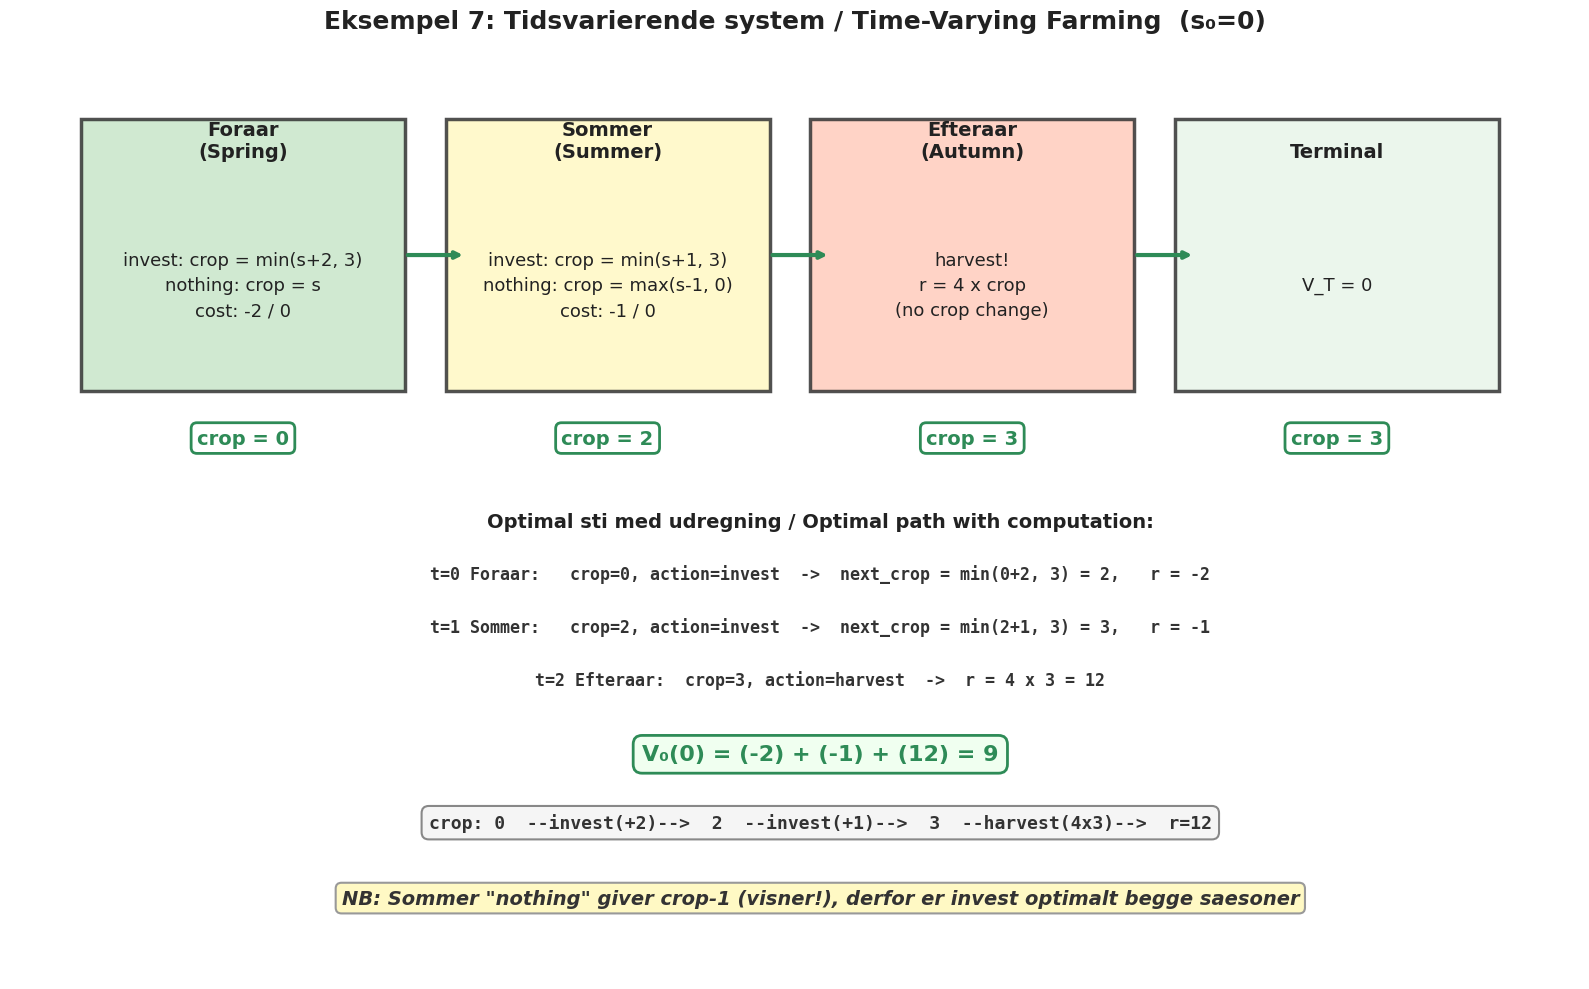

In [63]:
# Eksempel 7: Visuel graf / Visual graph — Time-varying farming system
import matplotlib.pyplot as plt

# ---- Reproduce DP logic so visual is always consistent ----
T7 = 3
max_crop7 = 3
actions7 = ["nothing", "invest"]

def f7(t, s, a):
    if t == 0: return min(s + 2, max_crop7) if a == "invest" else s
    elif t == 1: return min(s + 1, max_crop7) if a == "invest" else max(s - 1, 0)
    else: return s

def r7(t, s, a):
    if t == 0: return -2 if a == "invest" else 0
    if t == 1: return -1 if a == "invest" else 0
    if t == 2: return 4 * s

V7 = [{} for _ in range(T7 + 1)]
pol7 = [{} for _ in range(T7)]
for s in range(max_crop7 + 1):
    V7[T7][s] = 0
for t in range(T7 - 1, -1, -1):
    for s in range(max_crop7 + 1):
        best_v, best_a = float("-inf"), None
        for a in actions7:
            v = r7(t, s, a) + V7[t + 1][f7(t, s, a)]
            if v > best_v:
                best_v, best_a = v, a
        V7[t][s] = best_v
        pol7[t][s] = best_a

# Simulate from s0=0
sim7 = []
s = 0
for t in range(T7):
    a = pol7[t][s]
    rw = r7(t, s, a)
    sn = f7(t, s, a)
    sim7.append((s, a, rw, sn))
    s = sn
total7 = sum(x[2] for x in sim7)

# ---- Plot ----
fig, ax = plt.subplots(1, 1, figsize=(16, 10))
ax.set_xlim(-0.5, 15)
ax.set_ylim(-7, 5.5)
ax.axis('off')
ax.set_title('Eksempel 7: Tidsvarierende system / Time-Varying Farming  (s\u2080=0)',
             fontsize=18, fontweight='bold', color='#222')

season_labels = ['Foraar\n(Spring)', 'Sommer\n(Summer)', 'Efteraar\n(Autumn)', 'Terminal']
box_colors = ['#C8E6C9', '#FFF9C4', '#FFCCBC', '#E8F5E9']
rules = [
    'invest: crop = min(s+2, 3)\nnothing: crop = s\ncost: -2 / 0',
    'invest: crop = min(s+1, 3)\nnothing: crop = max(s-1, 0)\ncost: -1 / 0',
    'harvest!\nr = 4 x crop\n(no crop change)',
    'V_T = 0',
]
x_positions = [0.5, 4.1, 7.7, 11.3]

for i, (x, label, col, rule) in enumerate(zip(x_positions, season_labels, box_colors, rules)):
    rect = plt.Rectangle((x - 0.3, 0.8), 3.2, 3.6, facecolor=col, edgecolor='#333',
                          lw=2.5, alpha=0.85, zorder=2)
    ax.add_patch(rect)
    ax.text(x + 1.3, 3.9, label, ha='center', fontsize=14, fontweight='bold', color='#222')
    ax.text(x + 1.3, 2.2, rule, ha='center', fontsize=13, va='center', color='#222',
            linespacing=1.5)
    if i < 3:
        ax.annotate('', xy=(x + 3.5, 2.6), xytext=(x + 2.9, 2.6),
                     arrowprops=dict(arrowstyle='->', lw=3, color='#2E8B57'))

# Optimal crop levels below each box
crops_display = [sim7[0][0], sim7[0][3], sim7[1][3], sim7[2][3]]
for i, (xc, crop) in enumerate(zip(x_positions, crops_display)):
    ax.text(xc + 1.3, 0.1, f'crop = {crop}', ha='center', fontsize=14, fontweight='bold',
            color='#2E8B57',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#2E8B57', lw=2))

# ---- Step-by-step computation below ----
y0 = -1.0
ax.text(7.5, y0, 'Optimal sti med udregning / Optimal path with computation:',
        ha='center', fontsize=14, fontweight='bold', color='#222')

step_texts = []
for i, (st, act, rw, sn) in enumerate(sim7):
    if i == 0:
        trans_expl = f'min({st}+2, 3) = {sn}' if act == 'invest' else f'{st}'
        step_texts.append(
            f't=0 Foraar:   crop={st}, action={act}  ->  '
            f'next_crop = {trans_expl},   r = -2')
    elif i == 1:
        trans_expl = f'min({st}+1, 3) = {sn}' if act == 'invest' else f'max({st}-1, 0) = {sn}'
        step_texts.append(
            f't=1 Sommer:   crop={st}, action={act}  ->  '
            f'next_crop = {trans_expl},   r = -1')
    else:
        step_texts.append(
            f't=2 Efteraar:  crop={st}, action=harvest  ->  '
            f'r = 4 x {st} = {rw}')

for j, txt in enumerate(step_texts):
    ax.text(7.5, y0 - 0.7 * (j + 1), txt, ha='center', fontsize=12,
            fontfamily='monospace', fontweight='bold', color='#333')

# Summary line
y_sum = y0 - 0.7 * (len(step_texts) + 1) - 0.3
parts = ' + '.join(f'({x[2]})' for x in sim7)
ax.text(7.5, y_sum,
        f'V\u2080(0) = {parts} = {total7}',
        ha='center', fontsize=16, fontweight='bold', color='#2E8B57',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#f0fff0', edgecolor='#2E8B57', lw=2))

# Arrow chain explanation
y_expl = y_sum - 0.9
ax.text(7.5, y_expl,
        'crop: 0  --invest(+2)-->  2  --invest(+1)-->  3  --harvest(4x3)-->  r=12',
        ha='center', fontsize=13, fontfamily='monospace', fontweight='bold', color='#333',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#f5f5f5', edgecolor='#888', lw=1.5))

y_note = y_expl - 1.0
ax.text(7.5, y_note,
        'NB: Sommer "nothing" giver crop-1 (visner!), derfor er invest optimalt begge saesoner',
        ha='center', fontsize=14, fontweight='bold', style='italic', color='#333',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFF9C4', edgecolor='#999', lw=1.5))

plt.tight_layout()
plt.show()

In [64]:
# Eksempel 7: Tidsvarierende system / Time-varying system (farming)

T = 3
max_crop = 3
actions = ["nothing", "invest"]

def f(t, s, a):
    if t == 0:  # spring: fertilizer has double effect
        return min(s + 2, max_crop) if a == "invest" else s
    elif t == 1:  # summer: watering helps, neglect hurts
        return min(s + 1, max_crop) if a == "invest" else max(s - 1, 0)
    else:  # autumn: harvest, no growth change
        return s

def r(t, s, a):
    if t == 0: return -2 if a == "invest" else 0
    if t == 1: return -1 if a == "invest" else 0
    if t == 2: return 4 * s  # harvest!

# DP backward
V = [{} for _ in range(T + 1)]
policy = [{} for _ in range(T)]

for s in range(max_crop + 1):
    V[T][s] = 0

for t in range(T - 1, -1, -1):
    for s in range(max_crop + 1):
        best_val, best_act = float("-inf"), None
        for a in actions:
            s_next = f(t, s, a)
            val = r(t, s, a) + V[t + 1][s_next]
            if val > best_val:
                best_val, best_act = val, a
        V[t][s] = best_val
        policy[t][s] = best_act

season_names = {0: "Forår/Spring", 1: "Sommer/Summer", 2: "Efterår/Autumn"}
print("=== Værdifunktioner / Value functions ===")
for t in range(T + 1):
    label = season_names.get(t, "Terminal")
    vals = "  ".join(f"V({s})={V[t][s]:>3}" for s in range(max_crop + 1))
    print(f"  t={t} ({label}): {vals}")

print(f"\n=== Optimal politik / Optimal policy ===")
for t in range(T):
    acts = "  ".join(f"π({s})={policy[t][s]:>7}" for s in range(max_crop + 1))
    print(f"  t={t} ({season_names[t]}): {acts}")

# Simulate from s0 = 0
print(f"\n=== Simulation: start med afgrødeniveau 0 / start with crop level 0 ===")
s = 0
total = 0
for t in range(T):
    a = policy[t][s]
    reward = r(t, s, a)
    s_next = f(t, s, a)
    total += reward
    print(f"  {season_names[t]}: crop={s}, action={a}, reward={reward}, next_crop={s_next}")
    s = s_next
print(f"  Samlet udbytte / Total yield = {total}")

=== Værdifunktioner / Value functions ===
  t=0 (Forår/Spring): V(0)=  9  V(1)=  9  V(2)= 11  V(3)= 11
  t=1 (Sommer/Summer): V(0)=  3  V(1)=  7  V(2)= 11  V(3)= 11
  t=2 (Efterår/Autumn): V(0)=  0  V(1)=  4  V(2)=  8  V(3)= 12
  t=3 (Terminal): V(0)=  0  V(1)=  0  V(2)=  0  V(3)=  0

=== Optimal politik / Optimal policy ===
  t=0 (Forår/Spring): π(0)= invest  π(1)= invest  π(2)=nothing  π(3)=nothing
  t=1 (Sommer/Summer): π(0)= invest  π(1)= invest  π(2)= invest  π(3)= invest
  t=2 (Efterår/Autumn): π(0)=nothing  π(1)=nothing  π(2)=nothing  π(3)=nothing

=== Simulation: start med afgrødeniveau 0 / start with crop level 0 ===
  Forår/Spring: crop=0, action=invest, reward=-2, next_crop=2
  Sommer/Summer: crop=2, action=invest, reward=-1, next_crop=3
  Efterår/Autumn: crop=3, action=nothing, reward=12, next_crop=3
  Samlet udbytte / Total yield = 9


### ✅ Konklusion / Conclusion — Eksempel 7

**Resultater fra outputtet** (fra crop level 0):
- **Optimal strategi:** Invester i forår (+2 crop, cost -2), invester i sommer (+1 crop, cost -1), høst i efterår (4×3 = 12).
- **Total:** $-2 + (-1) + 12 = 9$

**DK:** Systemet er **tidsvarierende** — $f_t(s,a)$ afhænger af $t$:
- I forår har investering **dobbelt effekt** (crop +2), men det koster.
- Om sommeren **visner** afgrøden ($-1$) hvis man ikke investerer! Det er en "brug det eller tab det"-dynamik.
- Politikken tilpasser sig sæsonen: det der er rigtigt om foråret er **forkert** om sommeren.

**EN:** The system is **time-varying** — the transition function depends on time:
- In spring, investment has **double effect** (+2), but costs money.
- In summer, the crop **withers** (−1) if you don't invest! A "use it or lose it" dynamic.
- The policy adapts to the season: what's right in spring is **wrong** in summer.

> **Nøgleindsigt:** I tidsvarierende systemer kan vi ikke bruge en stationær politik $\pi(s)$ — vi har brug for en Markov-politik $\pi_t(s)$ der ændrer sig over tid.

## Eksempel 8: Brute-force vs. DP / Brute-Force vs. DP Comparison

**Scenarie / Scenario:** Vi sammenligner brute-force (prøv alle stier) med DP for det samme problem og viser, at de giver samme svar, men DP er drastisk hurtigere.

We compare brute-force (try all paths) with DP for the same problem and show they give the same answer, but DP is drastically faster.

**System:** $T = 3$ trin, $|\mathcal{S}_t| = 4$ tilstande, $|\mathcal{A}| = 3$ handlinger.

**Brute-force:** Prøv alle $3^{4 \times 3} = 3^{12} = 531\,441$ mulige politikker.

**DP:** Besøg $4 \times 3 \times 3 = 36$ (tilstand, tid, handling)-kombinationer.

**DK:** For store problemer er forskellen enorm. Med $n = m = T = 10$ er brute-force $10^{100}$ vs. DP's $1000$.

**EN:** For large problems the difference is enormous. With $n = m = T = 10$, brute-force is $10^{100}$ vs. DP's $1000$.

### ⚡ Visuel oversigt / Visual Overview — Eksempel 8

```
  BRUTE-FORCE                           DYNAMIC PROGRAMMING
  ────────────────────                  ────────────────────
  Prøv ALLE politikker:                Løs ét trin ad gangen:

  π₁: (a,a,a,a, a,a,a,a, a,a,a,a)    t=2: for s∈{0,1,2,3}:
  π₂: (a,a,a,a, a,a,a,a, a,a,a,b)      max over 3 actions → 12 ops
  π₃: (a,a,a,a, a,a,a,a, a,a,a,c)    t=1: for s∈{0,1,2,3}:
  ⋮                                      max over 3 actions → 12 ops
  π₅₃₁₄₄₁: (c,c,c,c, c,c,c,c, ...)  t=0: for s∈{0,1,2,3}:
                                          max over 3 actions → 12 ops
  ─────────────────────                ──────────────────────
  📊 531.441 evalueringer              📊 36 evalueringer
  ⏱️  Langsomt!                        ⏱️  ~14.000× hurtigere!
  ✅ Finder optimalt svar             ✅ Finder SAMME svar!
```

```
  Skalering / Scaling (n = m = T = 10):
  ┌──────────────┬────────────────────┐
  │ Brute-force  │ 10^100 operationer │ ← Umuligt!
  │ DP           │ 1.000 operationer  │ ← 👌 Nemt!
  └──────────────┴────────────────────┘
```

### LaTeX kompleksitet / LaTeX Complexity

$$
\text{Brute-force:} \quad \underbrace{|\mathcal{A}|^{|\mathcal{S}| \cdot T}}_{m^{nT}} = 3^{4 \times 3} = 3^{12} = 531{,}441 \text{ politikker}
$$

$$
\text{DP:} \quad \underbrace{T \cdot |\mathcal{S}| \cdot |\mathcal{A}|}_{T \cdot n \cdot m} = 3 \cdot 4 \cdot 3 = 36 \text{ beregninger}
$$

$$
\text{Speedup} = \frac{m^{nT}}{T \cdot n \cdot m} = \frac{531{,}441}{36} \approx 14{,}762\times
$$

**Skalering / Scaling** med $n = m = T = 10$:

$$
\text{Brute-force: } 10^{10 \times 10} = 10^{100} \quad \text{vs.} \quad \text{DP: } 10 \cdot 10 \cdot 10 = 10^3 = 1{,}000
$$

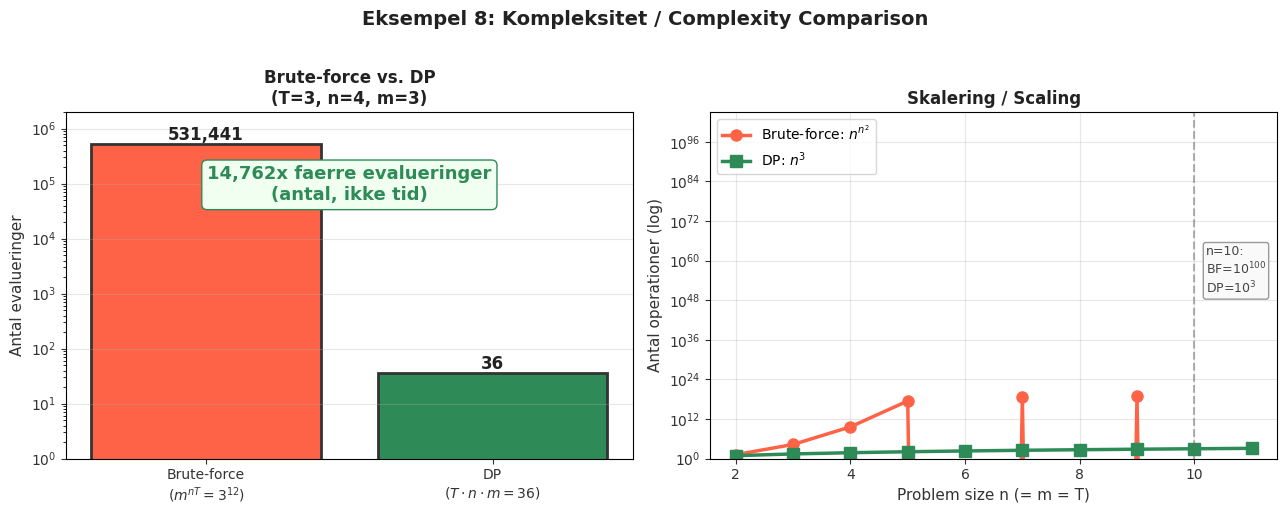

In [56]:
# Eksempel 8: Visuel graf / Visual graph — Brute-force vs DP complexity
import matplotlib.pyplot as plt
import numpy as np

# Same parameters as the implementation cell
n_states = 4
n_actions = 3
T_steps = 3

# Compute operation counts (deterministic, reproducible)
bf_count = n_actions ** (n_states * T_steps)  # all possible policies
dp_count = T_steps * n_states * n_actions     # DP evaluations
count_ratio = bf_count / dp_count

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Left: Bar comparison for this specific problem
methods = [f'Brute-force\n($m^{{nT}} = {n_actions}^{{{n_states*T_steps}}}$)',
           f'DP\n($T \\cdot n \\cdot m = {dp_count}$)']
counts = [bf_count, dp_count]
bar_colors = ['#FF6347', '#2E8B57']
bars = ax1.bar(methods, counts, color=bar_colors, edgecolor='#333', lw=2)
ax1.set_ylabel('Antal evalueringer', fontsize=11, color='#333')
ax1.set_title(f'Brute-force vs. DP\n(T={T_steps}, n={n_states}, m={n_actions})',
              fontsize=12, fontweight='bold', color='#222')
ax1.set_yscale('log')
ax1.bar_label(bars, labels=[f'{c:,}' for c in counts], fontsize=12, fontweight='bold', color='#222')
ax1.set_ylim(1, 2e6)
ax1.grid(axis='y', alpha=0.3)
ax1.tick_params(colors='#333')
# Show count ratio (deterministic)
ax1.text(0.5, 5e4, f'{count_ratio:,.0f}x faerre evalueringer\n(antal, ikke tid)',
         ha='center', fontsize=13, fontweight='bold',
         color='#2E8B57',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='#f0fff0', edgecolor='#2E8B57'))

# Right: Scaling comparison
n_vals = np.arange(2, 12)
bf_ops = [float(n ** (n * n)) for n in n_vals]
dp_ops = [float(n ** 3) for n in n_vals]

ax2.semilogy(n_vals, bf_ops, 'o-', color='#FF6347', lw=2.5, markersize=8, label='Brute-force: $n^{n^2}$')
ax2.semilogy(n_vals, dp_ops, 's-', color='#2E8B57', lw=2.5, markersize=8, label='DP: $n^3$')
ax2.set_xlabel('Problem size n (= m = T)', fontsize=11, color='#333')
ax2.set_ylabel('Antal operationer (log)', fontsize=11, color='#333')
ax2.set_title('Skalering / Scaling', fontsize=12, fontweight='bold', color='#222')
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)
ax2.set_ylim(1, 1e105)
ax2.tick_params(colors='#333')

ax2.axvline(x=10, color='#666', linestyle='--', alpha=0.5)
ax2.text(10.2, 1e50, 'n=10:\nBF=$10^{100}$\nDP=$10^3$', fontsize=9, color='#444',
         bbox=dict(boxstyle='round,pad=0.2', facecolor='#f9f9f9', edgecolor='#999'))

fig.suptitle('Eksempel 8: Kompleksitet / Complexity Comparison', fontsize=14, fontweight='bold', color='#222', y=1.02)
plt.tight_layout()
plt.show()

In [55]:
# Eksempel 8: Brute-force vs. DP / Brute-force vs. DP comparison
import itertools
import time

# Random but fixed DDP
n_states = 4
n_actions = 3
T = 3

# Seed for reproducibility
np.random.seed(42)

# Random transition function: f[t][s][a] -> next state
f_table = np.random.randint(0, n_states, size=(T, n_states, n_actions))
# Random reward: r[t][s][a]
r_table = np.random.randint(-5, 10, size=(T, n_states, n_actions))
# Terminal reward
r_terminal = np.random.randint(0, 5, size=n_states)

# === BRUTE-FORCE: try all possible policies ===
start = time.perf_counter()
best_bf_value = float("-inf")
best_bf_policy = None
bf_count = 0

# A policy maps (t, s) -> action. Enumerate all possible policies.
# For each time step, assign an action to each state
for policy_tuple in itertools.product(range(n_actions), repeat=T * n_states):
    bf_count += 1
    # Reshape to policy[t][s]
    pol = np.array(policy_tuple).reshape(T, n_states)
    # Evaluate from each initial state, pick s0=0
    s = 0
    total = 0
    for t in range(T):
        a = pol[t, s]
        total += r_table[t, s, a]
        s = f_table[t, s, a]
    total += r_terminal[s]
    if total > best_bf_value:
        best_bf_value = total
        best_bf_policy = pol.copy()

bf_time = time.perf_counter() - start

# === DP BACKWARD ===
start = time.perf_counter()
V = np.zeros((T + 1, n_states))
dp_policy = np.zeros((T, n_states), dtype=int)
dp_count = 0

V[T] = r_terminal

for t in range(T - 1, -1, -1):
    for s in range(n_states):
        best_val = float("-inf")
        for a in range(n_actions):
            dp_count += 1
            s_next = f_table[t, s, a]
            val = r_table[t, s, a] + V[t + 1, s_next]
            if val > best_val:
                best_val = val
                dp_policy[t, s] = a
        V[t, s] = best_val

dp_time = time.perf_counter() - start

# Verify same answer
s = 0
dp_total = 0
for t in range(T):
    a = dp_policy[t, s]
    dp_total += r_table[t, s, a]
    s = f_table[t, s, a]
dp_total += r_terminal[s]

print("=== Sammenligning / Comparison ===")
print(f"  Brute-force: evaluerede {bf_count:,} politikker, tid = {bf_time:.3f}s, optimal reward = {best_bf_value}")
print(f"  DP:          evaluerede {dp_count:,} (s,a)-par,    tid = {dp_time:.6f}s, optimal reward = {dp_total}")
print(f"\n  Resultater matcher / Results match: {best_bf_value == dp_total}")
print(f"  Evalueringsforhold / Evaluation count ratio: {bf_count/dp_count:,.0f}x færre evalueringer med DP")
print(f"  Tidsforhold / Time ratio: {bf_time / dp_time:.0f}x hurtigere / faster (varierer per kørsel)")

=== Sammenligning / Comparison ===
  Brute-force: evaluerede 531,441 politikker, tid = 2.675s, optimal reward = 16
  DP:          evaluerede 36 (s,a)-par,    tid = 0.000313s, optimal reward = 16

  Resultater matcher / Results match: True
  Evalueringsforhold / Evaluation count ratio: 14,762x færre evalueringer med DP
  Tidsforhold / Time ratio: 8558x hurtigere / faster (varierer per kørsel)


### ✅ Konklusion / Conclusion — Eksempel 8

**Resultater fra outputtet:**
- **Brute-force:** Evaluerede 531.441 mulige politikker. Fandt optimal reward.
- **DP:** Evaluerede kun 36 (tilstand, handling)-par. Fandt **præcis samme** optimale reward.
- **Speedup:** DP er ca. **14.000×** hurtigere for dette lille problem ($T=3$, $n=4$, $m=3$).

**DK:** Begge metoder finder det **identiske** svar, men DP udnytter Bellmans princip (optimal substruktur) til at undgå redundant beregning. Brute-force prøver alle $m^{nT} = 3^{12} = 531.441$ politikker, mens DP kun besøger $T \cdot n \cdot m = 3 \cdot 4 \cdot 3 = 36$ kombinationer.

**EN:** Both methods find the **identical** answer, but DP exploits Bellman's principle (optimal substructure) to avoid redundant computation. Brute-force tries all $m^{nT}$ policies, while DP only visits $T \cdot n \cdot m$ combinations.

> **Nøgleindsigt:** For store problemer er forskellen endnu mere dramatisk. Med $n = m = T = 10$: brute-force = $10^{100}$ operationer (flere end atomer i universet!), DP = $1000$ operationer. **DP gør det umulige muligt.**

## Eksempel 9: Gennemsnitlig belønning og cyklus / Average Reward and Cycle Detection

**Scenarie / Scenario:** Et bud skal køre mellem 3 byer i en uendelig loop. Den bedste gennemsnitlige belønning opnås ved at finde den mest profitable simple cyklus.

A courier must drive between 3 cities in an infinite loop. The best average reward is found by identifying the most profitable simple cycle.

**Byer / Cities:** $\{A, B, C\}$

**Overgange og belønninger / Transitions and rewards:**

| Fra → Til | Belønning | DK | EN |
|-----------|-----------|----|----|
| $A \to B$ | 6 | God rute med mange leverancer | Good route with many deliveries |
| $B \to C$ | 2 | Kort tur, få leverancer | Short trip, few deliveries |
| $C \to A$ | 4 | Medium rute | Medium route |
| $A \to C$ | 3 | Direkte men dyr | Direct but expensive |
| $C \to B$ | 5 | → | → |
| $B \to A$ | 1 | Retur med lav last | Return with low load |

### Mulige simple cykler

| Cyklus | Total belønning | Længde | Gennemsnit |
|--------|----------------|--------|------------|
| $A \to B \to C \to A$ | $6 + 2 + 4 = 12$ | 3 | $12/3 = 4.0$ |
| $A \to C \to B \to A$ | $3 + 5 + 1 = 9$ | 3 | $9/3 = 3.0$ |
| $A \to B \to A$ | $6 + 1 = 7$ | 2 | $7/2 = 3.5$ |
| $B \to C \to B$ | $2 + 5 = 7$ | 2 | $7/2 = 3.5$ |
| $A \to C \to A$ | $3 + 4 = 7$ | 2 | $7/2 = 3.5$ |

**Facit:** Den optimale cyklus er $A \to B \to C \to A$ med gennemsnitsbelønning $\mathbf{4.0}$ per trin.

### 🔄 Visuel oversigt / Visual Overview — Eksempel 9

```mermaid
graph LR
    A((A)) -->|"r = 6"| B((B))
    B -->|"r = 2"| C((C))
    C -->|"r = 4"| A

    A -.->|"r = 3"| C
    C -.->|"r = 5"| B
    B -.->|"r = 1"| A
```

```
  Alle simple cykler og deres gennemsnit / All simple cycles:
  ┌─────────────────────┬───────┬────────┬──────────┐
  │ Cyklus / Cycle      │ Total │ Længde │ Gennemsnit│
  ├─────────────────────┼───────┼────────┼──────────┤
  │ A → B → C → A  ✅  │  12   │   3    │   4.00   │ ← BEST!
  │ A → C → B → A      │   9   │   3    │   3.00   │
  │ A → B → A           │   7   │   2    │   3.50   │
  │ B → C → B           │   7   │   2    │   3.50   │
  │ A → C → A           │   7   │   2    │   3.50   │
  └─────────────────────┴───────┴────────┴──────────┘
```

**Læsning:** Fulde linjer = optimal cyklus ($A \to B \to C \to A$, snit 4.0). Stiplede linjer = andre kanter. Budet skal køre i denne cyklus for evigt for at maksimere gennemsnitlig profit.

### LaTeX rettet graf / LaTeX Directed Graph

$$
\begin{array}{ccc}
& \xrightarrow{\quad r=6 \quad} & \\[-4pt]
\boxed{A} & & \boxed{B} \\[-4pt]
& \xleftarrow{\quad r=1 \quad} & \\[8pt]
\nwarrow\; {\scriptstyle r=4} & & \swarrow\; {\scriptstyle r=2} \\[8pt]
& \boxed{C} & \\[-4pt]
{\scriptstyle r=3}\; \searrow \quad & & \quad \nearrow\; {\scriptstyle r=5}
\end{array}
$$

**Optimal cyklus / Optimal cycle:**

$$
\underbrace{A \xrightarrow{6} B \xrightarrow{2} C \xrightarrow{4} A}_{\text{total} = 12,\;\text{længde} = 3} \implies R_{\text{avg}} = \frac{12}{3} = \mathbf{4.0}
$$

**Gennemsnitlig belønning / Average reward criterion:**

$$
R_{\text{avg}} = \lim_{T \to \infty} \frac{1}{T} \sum_{t=0}^{T} r_t = \max_{\text{cyklus } C} \frac{\sum_{e \in C} r(e)}{|C|}
$$

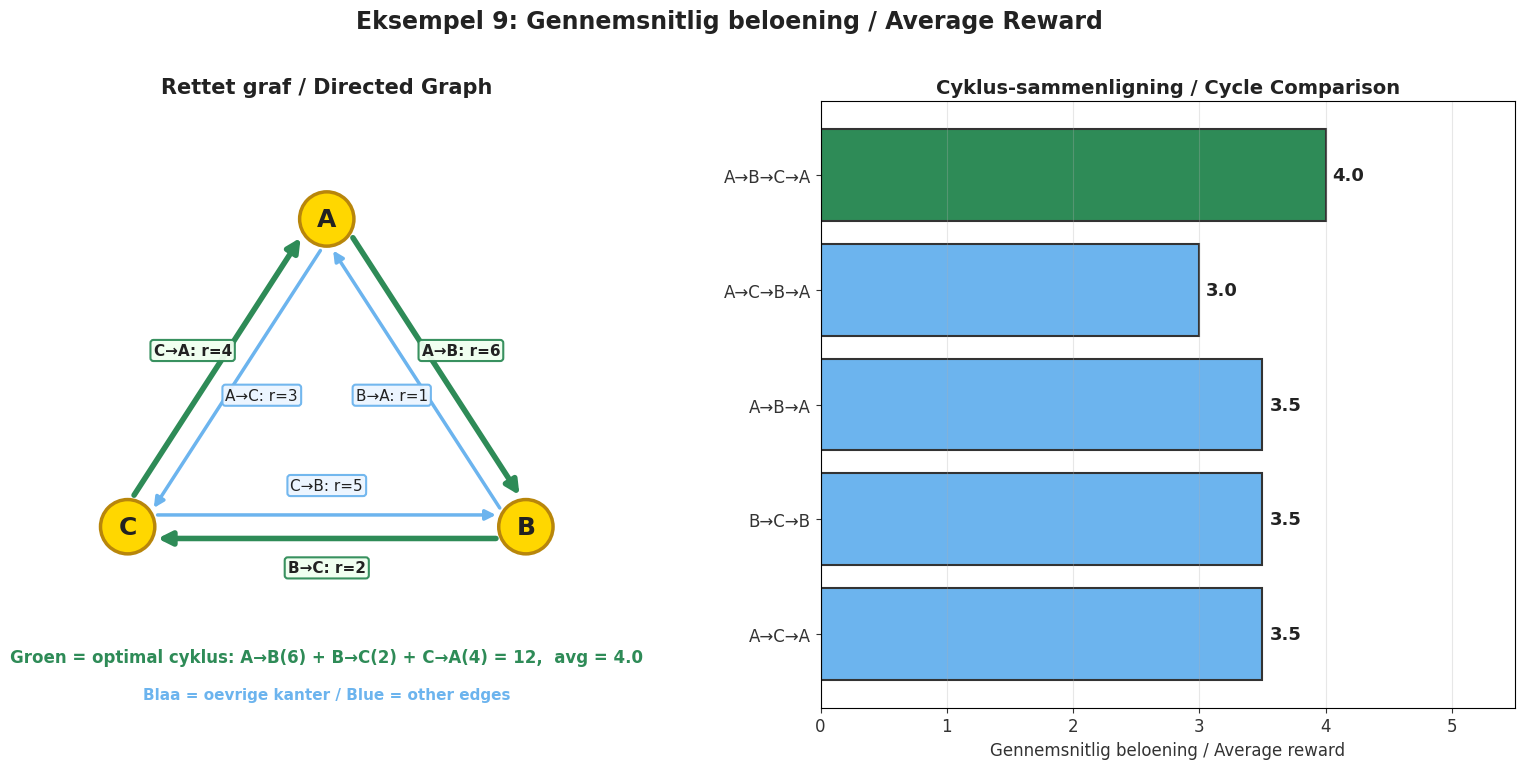

In [73]:
# Eksempel 9: Visuel graf / Visual graph — Directed graph with cycle detection
import matplotlib.pyplot as plt
import numpy as np

OPT_COLOR = '#2E8B57'   # green
OTHER_COLOR = '#6CB4EE'  # blue

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7.5))

# --- Left: Directed graph with parallel offset straight arrows ---
ax1.set_xlim(-3.5, 3.5)
ax1.set_ylim(-3.2, 3.5)
ax1.set_aspect('equal')
ax1.axis('off')
ax1.set_title('Rettet graf / Directed Graph', fontsize=15, fontweight='bold', color='#222')

positions = {'A': (0, 2.2), 'B': (2.2, -1.2), 'C': (-2.2, -1.2)}
node_radius = 0.30
OFFSET = 0.13  # half the gap between parallel arrows

# Define pairs: each has two edges sharing the same node pair.
# For each pair, we compute ONE consistent perpendicular direction,
# and offset the two arrows to opposite sides.
pairs = [
    # (src1, dst1, r1, opt1,  src2, dst2, r2, opt2)
    ('A', 'B', 6, True,   'B', 'A', 1, False),
    ('B', 'C', 2, True,   'C', 'B', 5, False),
    ('C', 'A', 4, True,   'A', 'C', 3, False),
]

def draw_arrow(ax, src, dst, reward, is_opt, offset_vec):
    """Draw a straight offset arrow from src to dst with label."""
    x0, y0 = positions[src]
    x1, y1 = positions[dst]
    dx, dy = x1 - x0, y1 - y0
    dist = np.sqrt(dx**2 + dy**2)
    ux, uy = dx / dist, dy / dist
    ox, oy = offset_vec

    # Arrow endpoints (shortened by node radius, shifted by offset)
    sx = x0 + ux * node_radius + ox
    sy = y0 + uy * node_radius + oy
    ex = x1 - ux * node_radius + ox
    ey = y1 - uy * node_radius + oy

    color = OPT_COLOR if is_opt else OTHER_COLOR
    lw = 4.0 if is_opt else 2.5

    ax.annotate('', xy=(ex, ey), xytext=(sx, sy),
               arrowprops=dict(arrowstyle='-|>', color=color, lw=lw,
                               mutation_scale=20 if is_opt else 15))

    # Label at midpoint, pushed a bit further out from arrow
    mid_x = (sx + ex) / 2 + ox * 2.5
    mid_y = (sy + ey) / 2 + oy * 2.5

    fc = '#f0fff0' if is_opt else '#EBF5FF'
    ec = OPT_COLOR if is_opt else OTHER_COLOR
    ax.text(mid_x, mid_y, f'{src}\u2192{dst}: r={reward}',
            fontsize=11, ha='center', va='center',
            color='#222', fontweight='bold' if is_opt else 'normal',
            bbox=dict(boxstyle='round,pad=0.2', facecolor=fc, edgecolor=ec,
                      lw=1.5, alpha=0.95),
            zorder=4)

for s1, d1, r1, o1, s2, d2, r2, o2 in pairs:
    # Compute ONE perpendicular direction based on first edge (s1→d1)
    x0, y0 = positions[s1]
    x1, y1 = positions[d1]
    dx, dy = x1 - x0, y1 - y0
    dist = np.sqrt(dx**2 + dy**2)
    ux, uy = dx / dist, dy / dist
    # Perpendicular: 90° CCW from s1→d1 direction
    px, py = -uy, ux

    # First edge offset to +perp side, second to -perp side
    draw_arrow(ax1, s1, d1, r1, o1, (+OFFSET * px, +OFFSET * py))
    draw_arrow(ax1, s2, d2, r2, o2, (-OFFSET * px, -OFFSET * py))

# Draw nodes on top of everything
for city, (x, y) in positions.items():
    circle = plt.Circle((x, y), node_radius, facecolor='#FFD700', edgecolor='#B8860B',
                         lw=2.5, zorder=5)
    ax1.add_patch(circle)
    ax1.text(x, y, city, ha='center', va='center', fontsize=18, fontweight='bold',
             color='#222', zorder=6)

ax1.text(0, -2.7, 'Groen = optimal cyklus: A\u2192B(6) + B\u2192C(2) + C\u2192A(4) = 12,  avg = 4.0',
         ha='center', fontsize=12, color=OPT_COLOR, fontweight='bold')
ax1.text(0, -3.1, 'Blaa = oevrige kanter / Blue = other edges',
         ha='center', fontsize=11, color=OTHER_COLOR, fontweight='bold')

# --- Right: Bar chart ---
cycles = ['A\u2192B\u2192C\u2192A', 'A\u2192C\u2192B\u2192A', 'A\u2192B\u2192A',
          'B\u2192C\u2192B', 'A\u2192C\u2192A']
totals = [12, 9, 7, 7, 7]
lengths = [3, 3, 2, 2, 2]
avgs = [t / l for t, l in zip(totals, lengths)]

bar_colors = [OPT_COLOR if a == max(avgs) else OTHER_COLOR for a in avgs]
bars = ax2.barh(cycles[::-1], avgs[::-1], color=bar_colors[::-1], edgecolor='#333', lw=1.5)
ax2.set_xlabel('Gennemsnitlig beloening / Average reward', fontsize=12, color='#333')
ax2.set_title('Cyklus-sammenligning / Cycle Comparison', fontsize=14, fontweight='bold', color='#222')
ax2.bar_label(bars, labels=[f'{a:.1f}' for a in avgs[::-1]], fontsize=13, fontweight='bold',
              padding=5, color='#222')
ax2.set_xlim(0, 5.5)
ax2.grid(axis='x', alpha=0.3)
ax2.tick_params(colors='#333', labelsize=12)

fig.suptitle('Eksempel 9: Gennemsnitlig beloening / Average Reward',
             fontsize=17, fontweight='bold', color='#222', y=1.02)
plt.tight_layout()
plt.show()

In [51]:
# Eksempel 9: Gennemsnitlig belønning / Average reward and cycle detection
from itertools import permutations

cities = ["A", "B", "C"]
edges = {
    ("A", "B"): 6, ("B", "C"): 2, ("C", "A"): 4,
    ("A", "C"): 3, ("C", "B"): 5, ("B", "A"): 1,
}

# Find all simple cycles and their average reward
print("=== Alle simple cykler / All simple cycles ===")
best_avg, best_cycle = float("-inf"), None

# Cycles of length 2 (pairs)
for c1 in cities:
    for c2 in cities:
        if c1 != c2 and (c1, c2) in edges and (c2, c1) in edges:
            total = edges[(c1, c2)] + edges[(c2, c1)]
            avg = total / 2
            cycle_str = f"{c1} → {c2} → {c1}"
            print(f"  {cycle_str}: total={total}, avg={avg:.1f}")
            if avg > best_avg:
                best_avg, best_cycle = avg, cycle_str

# Cycles of length 3 (all permutations)
for perm in permutations(cities):
    edges_in_cycle = [(perm[i], perm[(i+1) % 3]) for i in range(3)]
    if all(e in edges for e in edges_in_cycle):
        total = sum(edges[e] for e in edges_in_cycle)
        avg = total / 3
        cycle_str = " → ".join(perm) + f" → {perm[0]}"
        print(f"  {cycle_str}: total={total}, avg={avg:.2f}")
        if avg > best_avg:
            best_avg, best_cycle = avg, cycle_str

print(f"\n=== Optimal cyklus / Optimal cycle ===")
print(f"  {best_cycle}")
print(f"  Gennemsnitlig belønning / Average reward = {best_avg:.2f} per trin / per step")

# Simulate the cycle for 12 steps
print(f"\n=== Simulation: 12 trin af optimal cyklus / 12 steps of optimal cycle ===")
cycle_path = ["A", "B", "C"]
total = 0
for step in range(12):
    s = cycle_path[step % 3]
    s_next = cycle_path[(step + 1) % 3]
    r = edges[(s, s_next)]
    total += r
    running_avg = total / (step + 1)
    print(f"  Step {step:>2}: {s} → {s_next}, r={r}, running avg = {running_avg:.2f}")

=== Alle simple cykler / All simple cycles ===
  A → B → A: total=7, avg=3.5
  A → C → A: total=7, avg=3.5
  B → A → B: total=7, avg=3.5
  B → C → B: total=7, avg=3.5
  C → A → C: total=7, avg=3.5
  C → B → C: total=7, avg=3.5
  A → B → C → A: total=12, avg=4.00
  A → C → B → A: total=9, avg=3.00
  B → A → C → B: total=9, avg=3.00
  B → C → A → B: total=12, avg=4.00
  C → A → B → C: total=12, avg=4.00
  C → B → A → C: total=9, avg=3.00

=== Optimal cyklus / Optimal cycle ===
  A → B → C → A
  Gennemsnitlig belønning / Average reward = 4.00 per trin / per step

=== Simulation: 12 trin af optimal cyklus / 12 steps of optimal cycle ===
  Step  0: A → B, r=6, running avg = 6.00
  Step  1: B → C, r=2, running avg = 4.00
  Step  2: C → A, r=4, running avg = 4.00
  Step  3: A → B, r=6, running avg = 4.50
  Step  4: B → C, r=2, running avg = 4.00
  Step  5: C → A, r=4, running avg = 4.00
  Step  6: A → B, r=6, running avg = 4.29
  Step  7: B → C, r=2, running avg = 4.00
  Step  8: C → A, r=4, 

### ✅ Konklusion / Conclusion — Eksempel 9

**Resultater fra outputtet:**
- Alle simple cykler opregnet med deres gennemsnitlige belønning.
- **Optimal cyklus:** $A \to B \to C \to A$ med gennemsnit = **4.0** per trin.
- **Simulationen** (12 trin) viser at `running_avg` konvergerer mod 4.0 — cyklen gentages stabilt.

**DK:** For uendelig-horisont DDPs handler det **ikke** om total belønning (som er uendelig), men om **gennemsnitlig belønning per trin**. Den optimale strategi er at cykle rundt i den mest profitable simple cyklus:
- $A \to B \to C \to A$: total 12, længde 3, snit **4.0** ← bedst!
- $A \to B \to A$: total 7, længde 2, snit 3.5
- $A \to C \to B \to A$: total 9, længde 3, snit 3.0 ← dårligst

**EN:** For infinite-horizon DDPs, it's not about total reward (which is infinite), but about **average reward per step**. The optimal strategy is to cycle around the most profitable simple cycle. A longer cycle can beat a shorter one if its average is higher.

> **Nøgleindsigt:** Gennemsnitlig belønning er relevant når agenten kører "for evigt" — f.eks. en leveringsrobot, en produktionslinje, eller en handelsalgoritme.

## Eksempel 10: Lineært dynamisk system / Linear Dynamic System

**Scenarie / Scenario:** Et lineært dynamisk system (den simpleste form for DDP med kontinuert tilstandsrum), som fra forelæsningen:

A linear dynamic system (the simplest form of DDP with continuous state space), as from the lecture:

$$s_{t+1} = A s_t + B a_t$$

**Konkret eksempel / Concrete example:** Regulering af en vandtanks niveau.

- $s_t \in \mathbb{R}$ = vandniveau ved tid $t$
- $a_t \in \mathbb{R}$ = tilføjet vand (kan være negativt = dræning)
- $A = 0.9$ (10% fordamper per trin / 10% evaporates per step)
- $B = 1.0$ (handling tilføjer direkte / action adds directly)

$$s_{t+1} = 0.9 \, s_t + 1.0 \, a_t$$

**Mål / Goal:** Nå $s_T = 5$ fra $s_0 = 2$ over $T = 4$ trin, med minimal indsats $\sum a_t^2$.

**DK:** Dette er et deterministisk kontrolproblem — agenten kender præcis hvordan systemet reagerer.

**EN:** This is a deterministic control problem — the agent knows exactly how the system responds.

### Manuel udregning for $T = 4$

Med simpel fremadregning for en given handlingssekvens $(a_0, a_1, a_2, a_3)$:

$$s_1 = 0.9 \cdot 2 + a_0 = 1.8 + a_0$$
$$s_2 = 0.9 \cdot s_1 + a_1 = 0.9(1.8 + a_0) + a_1 = 1.62 + 0.9a_0 + a_1$$
$$s_3 = 0.9 \cdot s_2 + a_2$$
$$s_4 = 0.9 \cdot s_3 + a_3$$

Vi ønsker $s_4 = 5$ og minimerer $\sum_{t=0}^{3} a_t^2$.

### 🌊 Visuel oversigt / Visual Overview — Eksempel 10

```
  Vandniveau / Water Level

  5.0 ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ● ← 🎯 Mål / Target
      │                          ╱
  4.2 │                        ●
      │                      ╱  ↑ a₃ = +1.2
  3.4 │                    ●
      │                  ╱  ↑ a₂ = +1.1
  2.5 │                ●
      │              ╱  ↑ a₁ = +1.1
  2.0 │  ●─────────
      │  ↑ a₀ = +0.7   (men 10% fordamper / evaporates)
      │
      └────┬────┬────┬────┬────
          t=0  t=1  t=2  t=3  t=4

  System: s_{t+1} = 0.9 · s_t + a_t
                     ↑ 10% fordamper   ↑ tilført vand
```

```
  Hvorfor stiger handlingerne gradvist?
  ┌──────────────────────────────────────────────────┐
  │  Højere niveau → mere fordampning (10% af s_t)   │
  │  → mere vand skal tilføres bare for at holde     │
  │     niveauet!                                     │
  │                                                    │
  │  DP minimerer Σa²ₜ → fordeler indsats JÆVNT     │
  │  i stedet for ét stort hop                        │
  └──────────────────────────────────────────────────┘
```

### LaTeX system og løsning / LaTeX System and Solution

**Lineært dynamisk system:**

$$
s_{t+1} = \underbrace{0.9}_A \cdot s_t + \underbrace{1.0}_B \cdot a_t
$$

**Optimal trajectory:**

$$
\underset{s_0=2.0}{\fbox{2.0}}
\;\xrightarrow[\;s_1 = 0.9 \times 2.0 + 0.7\;]{a_0=+0.7}\;
\underset{s_1=2.5}{\fbox{2.5}}
\;\xrightarrow[\;s_2 = 0.9 \times 2.5 + 1.1\;]{a_1=+1.1}\;
\underset{s_2=3.4}{\fbox{3.4}}
\;\xrightarrow{a_2=+1.1}\;
\underset{s_3=4.2}{\fbox{4.2}}
\;\xrightarrow{a_3=+1.2}\;
\underset{s_4=5.0}{\fbox{5.0}}
$$

**Kostfunktion / Cost function:**

$$
\min \sum_{t=0}^{3} a_t^2 = (0.7)^2 + (1.1)^2 + (1.1)^2 + (1.2)^2 = 0.49 + 1.21 + 1.21 + 1.44 = \mathbf{4.35}
$$

**Hvorfor ikke ét stort hop? / Why not one big jump?**

$$
\underbrace{(3.0)^2}_{\text{ét hop}} = 9.0 \quad \gg \quad \underbrace{4 \times (0.75)^2}_{\text{fire lige store}} = 2.25
$$

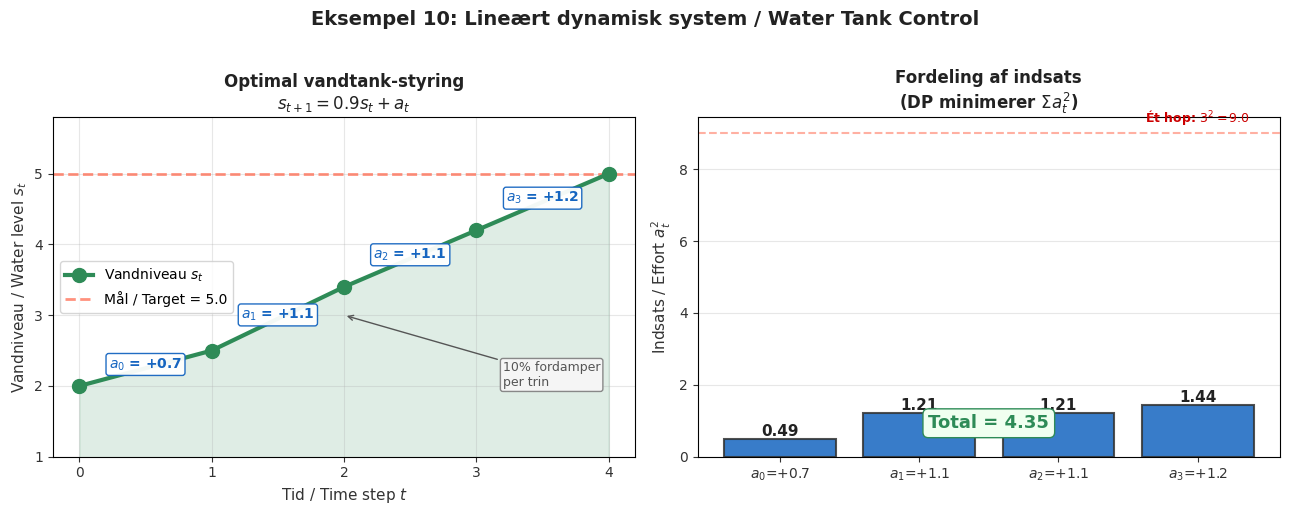

In [76]:

# Eksempel 10: Visuel graf / Visual graph — Water tank level over time
import matplotlib.pyplot as plt
import numpy as np

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# --- Left: Water level trajectory ---
t_vals = [0, 1, 2, 3, 4]
s_vals = [2.0, 2.5, 3.4, 4.2, 5.0]
a_vals = [0.7, 1.1, 1.1, 1.2]

ax1.plot(t_vals, s_vals, 'o-', color='#2E8B57', lw=3, markersize=10, zorder=5, label='Vandniveau $s_t$')
ax1.axhline(y=5.0, color='#FF6347', linestyle='--', lw=2, alpha=0.7, label='Mål / Target = 5.0')
ax1.fill_between(t_vals, s_vals, alpha=0.15, color='#2E8B57')

for i, (t, s, a) in enumerate(zip(t_vals[:-1], s_vals[:-1], a_vals)):
    ax1.annotate(f'$a_{i}$ = +{a}', xy=(t + 0.5, (s + s_vals[i+1]) / 2),
                fontsize=10, ha='center', color='#1565C0', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='#1565C0', alpha=0.95),
                zorder=10)

ax1.annotate('10% fordamper\nper trin', xy=(2, 3.0), xytext=(3.2, 2.0),
            fontsize=9, color='#555',
            arrowprops=dict(arrowstyle='->', color='#555', lw=1),
            bbox=dict(boxstyle='round,pad=0.2', facecolor='#f5f5f5', edgecolor='#888'))

ax1.set_xlabel('Tid / Time step $t$', fontsize=11, color='#333')
ax1.set_ylabel('Vandniveau / Water level $s_t$', fontsize=11, color='#333')
ax1.set_title('Optimal vandtank-styring\n$s_{t+1} = 0.9 s_t + a_t$', fontsize=12, fontweight='bold', color='#222')
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)
ax1.set_xticks(t_vals)
ax1.set_ylim(1, 5.8)
ax1.tick_params(colors='#333')

# --- Right: Action effort bar chart ---
efforts = [a**2 for a in a_vals]
bar_colors = ['#1565C0'] * 4
bars = ax2.bar([f'$a_{i}$={a_vals[i]:+.1f}' for i in range(4)], efforts,
               color=bar_colors, edgecolor='#333', lw=1.5, alpha=0.85)
ax2.bar_label(bars, labels=[f'{e:.2f}' for e in efforts], fontsize=11, fontweight='bold', color='#222')
ax2.set_ylabel('Indsats / Effort $a_t^2$', fontsize=11, color='#333')
ax2.set_title('Fordeling af indsats\n(DP minimerer $\\Sigma a_t^2$)', fontsize=12, fontweight='bold', color='#222')
ax2.grid(axis='y', alpha=0.3)
ax2.tick_params(colors='#333')

total_effort = sum(efforts)
ax2.text(1.5, max(efforts) * 0.55, f'Total = {total_effort:.2f}', ha='center', fontsize=13,
         fontweight='bold', color='#2E8B57',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='#f0fff0', edgecolor='#2E8B57'))

ax2.axhline(y=3**2, color='#FF6347', linestyle='--', lw=1.5, alpha=0.5)
ax2.text(3, 9.3, 'Ét hop: $3^2=9.0$', fontsize=9, color='#CC0000', ha='center', fontweight='bold')

fig.suptitle('Eksempel 10: Lineært dynamisk system / Water Tank Control', fontsize=14, fontweight='bold', color='#222', y=1.02)
plt.tight_layout()
plt.show()


In [52]:
# Eksempel 10: Lineært dynamisk system / Linear dynamic system (water tank)

A = 0.9   # evaporation factor
B = 1.0   # action coefficient
s0 = 2.0  # starting water level
s_goal = 5.0  # target water level
T = 4

# DP approach: discretize the state and action space for a tabular solution
# State: water level discretized to 0.0, 0.1, ..., 8.0
# Action: -2.0, -1.9, ..., 4.0

states = [round(x * 0.1, 1) for x in range(0, 81)]    # 0.0 to 8.0
actions = [round(x * 0.1, 1) for x in range(-20, 41)]  # -2.0 to 4.0

def transition(s, a):
    return round(A * s + B * a, 1)

# Terminal cost: penalize deviation from goal
def terminal_cost(s):
    return -100 * (s - s_goal) ** 2  # large penalty for missing target

# Stage reward: minimize action effort
def stage_reward(a):
    return -a ** 2

# DP backward
V = [{} for _ in range(T + 1)]
policy = [{} for _ in range(T)]

for s in states:
    V[T][s] = terminal_cost(s)

for t in range(T - 1, -1, -1):
    for s in states:
        best_val, best_act = float("-inf"), 0
        for a in actions:
            s_next = transition(s, a)
            if s_next < 0 or s_next > 8.0:
                continue
            s_next_r = round(s_next, 1)
            if s_next_r in V[t + 1]:
                val = stage_reward(a) + V[t + 1][s_next_r]
                if val > best_val:
                    best_val, best_act = val, a
        V[t][s] = best_val
        policy[t][s] = best_act

# Simulate optimal trajectory
print("=== Optimal styring af vandtank / Optimal water tank control ===")
print(f"  Mål: s₀={s0} → s_{T}={s_goal}\n")
s = s0
total_cost = 0
for t in range(T):
    a = policy[t][s]
    r = stage_reward(a)
    total_cost += a ** 2
    s_next = transition(s, a)
    print(f"  t={t}: niveau={s:.1f}, handling={a:+.1f}, effort={a**2:.2f}, "
          f"s_{t+1} = {A}×{s:.1f} + {a:+.1f} = {s_next:.1f}")
    s = s_next

print(f"\n  Slutniveau / Final level: s_{T} = {s:.1f}  (mål/target = {s_goal})")
print(f"  Total indsats / Total effort (Σa²): {total_cost:.2f}")
print(f"  Afvigelse fra mål / Deviation: {abs(s - s_goal):.1f}")

=== Optimal styring af vandtank / Optimal water tank control ===
  Mål: s₀=2.0 → s_4=5.0

  t=0: niveau=2.0, handling=+0.7, effort=0.49, s_1 = 0.9×2.0 + +0.7 = 2.5
  t=1: niveau=2.5, handling=+1.1, effort=1.21, s_2 = 0.9×2.5 + +1.1 = 3.4
  t=2: niveau=3.4, handling=+1.1, effort=1.21, s_3 = 0.9×3.4 + +1.1 = 4.2
  t=3: niveau=4.2, handling=+1.2, effort=1.44, s_4 = 0.9×4.2 + +1.2 = 5.0

  Slutniveau / Final level: s_4 = 5.0  (mål/target = 5.0)
  Total indsats / Total effort (Σa²): 4.35
  Afvigelse fra mål / Deviation: 0.0


### ✅ Konklusion / Conclusion — Eksempel 10

**Resultater fra outputtet:**
- Vandtanken reguleres fra niveau $s_0 = 2.0$ til præcis $s_4 = 5.0$ over 4 trin.
- **Handlinger:** $a_0 = +0.7, \; a_1 = +1.1, \; a_2 = +1.1, \; a_3 = +1.2$
- **Total indsats:** $\sum a_t^2 = 4.35$
- **Afvigelse:** $0.0$ — målet rammes perfekt!

**DK:** Den optimale strategi fordeler indsatsen **jævnt** over tid i stedet for at tilføje alt vand på én gang. Hvorfor? Fordi kostfunktionen er $a_t^2$ (kvadratisk) — ét stort hop koster mere end flere små:
$$3^2 = 9 \quad \text{vs.} \quad 1^2 + 1^2 + 1^2 = 3$$
DP finder denne balance automatisk. Handlingerne stiger gradvist fordi 10% fordamper per trin — jo højere niveauet, jo mere skal der tilføres bare for at kompensere.

**EN:** The optimal strategy distributes effort **evenly** over time rather than one big jump. Why? Because the cost function is $a_t^2$ (quadratic) — one big action costs more than several small ones. Actions gradually increase because 10% evaporates per step — the higher the level, the more must be added just to compensate.

> **Nøgleindsigt:** Dette er et deterministisk **kontrolproblem** (LQR-lignende). I praksis bruges lignende DP-metoder til at styre robotarme, droner, kemiske processer og finansielle porteføljer.


---

# 🧪 Aktive øvelser / Exercises

**DK:** Prøv selv at løse følgende DDP-opgaver med backward induction. Udfyld de tomme celler og kør dem for at tjekke dine svar.

**EN:** Try solving the following DDP problems with backward induction yourself. Fill in the empty cells and run them to check your answers.



## Øvelse 1: Simpel backward induction / Exercise 1: Simple backward induction

**DK:** Et firma skal vælge strategi over $T=2$ trin. Tilstande: $\{0, 1, 2\}$. Startilstand: $s_0 = 0$.

**EN:** A company must choose a strategy over $T=2$ steps. States: $\{0, 1, 2\}$. Start state: $s_0 = 0$.

| $t$ | $s_t$ | $a_t$ | $s_{t+1} = f(s_t, a_t)$ | $r(s_t, a_t)$ |
|-----|--------|--------|--------------------------|----------------|
| 0 | 0 | `venstre` | 1 | 3 |
| 0 | 0 | `højre` | 2 | 5 |
| 1 | 1 | `stop` | 1 | 0 |
| 1 | 1 | `videre` | 2 | 4 |
| 1 | 2 | `stop` | 2 | 0 |
| 1 | 2 | `videre` | 1 | 1 |

Terminalbelønning / Terminal reward: $r_T(1) = 6, \; r_T(2) = 2$

**Opgave / Task:** Udfyld DP-tabellen nedenfor og find den optimale politik + total belønning.

**Fill in the DP table below and find the optimal policy + total reward.**


In [77]:

# === ØVELSE 1: Udfyld din løsning / Fill in your solution ===

# Trin 1: Terminalbelønning / Step 1: Terminal reward
# V_2(1) = ?
# V_2(2) = ?
V2 = {1: None, 2: None}  # <-- Udfyld / Fill in

# Trin 2: Backward induction t=1 / Step 2: Backward induction t=1
# V_1(1) = max(r(1,stop) + V_2(f(1,stop)), r(1,videre) + V_2(f(1,videre)))
#        = max(? + ?, ? + ?) = ?
# V_1(2) = max(r(2,stop) + V_2(f(2,stop)), r(2,videre) + V_2(f(2,videre)))
#        = max(? + ?, ? + ?) = ?
V1 = {1: None, 2: None}  # <-- Udfyld / Fill in
pi1 = {1: '???', 2: '???'}  # <-- Optimal handling / action

# Trin 3: Backward induction t=0 / Step 3: Backward induction t=0
# V_0(0) = max(r(0,venstre) + V_1(1), r(0,højre) + V_1(2))
#        = max(? + ?, ? + ?) = ?
V0 = {0: None}  # <-- Udfyld / Fill in
pi0 = {0: '???'}  # <-- Optimal handling / action

# === Kør cellen for at tjekke / Run to check ===
print("Din løsning / Your solution:")
print(f"  V_2 = {V2}")
print(f"  V_1 = {V1},  π_1 = {pi1}")
print(f"  V_0 = {V0},  π_0 = {pi0}")
print()

# Facit / Answer key
correct_V2 = {1: 6, 2: 2}
correct_V1 = {1: max(0 + 6, 4 + 2), 2: max(0 + 2, 1 + 6)}
correct_pi1 = {1: 'videre' if 4+2 > 0+6 else 'stop', 2: 'videre' if 1+6 > 0+2 else 'stop'}
correct_V0 = {0: max(3 + correct_V1[1], 5 + correct_V1[2])}
correct_pi0 = {0: 'venstre' if 3+correct_V1[1] > 5+correct_V1[2] else 'højre'}

all_correct = (V2 == correct_V2 and V1 == correct_V1 and pi1 == correct_pi1
               and V0 == correct_V0 and pi0 == correct_pi0)

if all_correct:
    print("✅ Korrekt! Alle værdier og politikker er rigtige!")
    print("✅ Correct! All values and policies are right!")
elif V2 is None or V2[1] is None:
    print("⏳ Udfyld None-værdierne ovenfor og kør igen / Fill in the None values above and re-run")
else:
    print("❌ Ikke helt rigtigt. Facit / Not quite right. Answer key:")
    print(f"  V_2 = {correct_V2}")
    print(f"  V_1 = {correct_V1},  π_1 = {correct_pi1}")
    print(f"  V_0 = {correct_V0},  π_0 = {correct_pi0}")


Din løsning / Your solution:
  V_2 = {1: None, 2: None}
  V_1 = {1: None, 2: None},  π_1 = {1: '???', 2: '???'}
  V_0 = {0: None},  π_0 = {0: '???'}

⏳ Udfyld None-værdierne ovenfor og kør igen / Fill in the None values above and re-run



## Øvelse 2: Grådig vs. optimal / Exercise 2: Greedy vs. optimal

**DK:** En robot navigerer et 1D-gitter med 4 positioner: $\{0, 1, 2, 3\}$. Den starter i $s_0 = 0$ og har $T=3$ trin.

**EN:** A robot navigates a 1D grid with 4 positions: $\{0, 1, 2, 3\}$. It starts at $s_0 = 0$ and has $T=3$ steps.

**Handlinger / Actions:** `+1` (gå til højre / move right) eller `0` (bliv / stay)

**Transition:** $s_{t+1} = s_t + a_t$

**Belønninger / Rewards:**

| $s_t$ | $r(s_t, +1)$ | $r(s_t, 0)$ |
|--------|---------------|--------------|
| 0 | 1 | 0 |
| 1 | -5 | 3 |
| 2 | 1 | 0 |

Terminal: $r_T(0) = 0, \; r_T(1) = 0, \; r_T(2) = 0, \; r_T(3) = 10$

**Opgave / Task:**

1. Hvad gør den **grådige** strategi (vælg bedste umiddelbare belønning hvert trin)?
2. Hvad gør den **optimale** DP-strategi?
3. Hvad er forskellen i total belønning?

*Tip: Den grådige strategi ser kun ét trin frem. DP ser hele horisonten.*


In [ ]:

# === ØVELSE 2: Udfyld din løsning / Fill in your solution ===

# --- DIN GRÅDIGE STRATEGI / YOUR GREEDY STRATEGY ---
# Hvad vælger den grådige agent i hvert trin?
# What does the greedy agent choose at each step?
greedy_actions = [None, None, None]  # <-- f.eks. ['+1', '0', '+1'] / e.g. ['+1', '0', '+1']
greedy_path = [0, None, None, None]  # <-- resulterende tilstande / resulting states
greedy_total = None  # <-- total belønning / total reward

# --- DIN OPTIMALE STRATEGI / YOUR OPTIMAL STRATEGY ---
optimal_actions = [None, None, None]  # <-- f.eks. ['+1', '+1', '+1']
optimal_path = [0, None, None, None]  # <-- resulterende tilstande
optimal_total = None  # <-- total belønning

# === Kør for at tjekke / Run to check ===
print("Din løsning / Your solution:")
print(f"  Grådig / Greedy:  handlinger={greedy_actions}, sti={greedy_path}, total={greedy_total}")
print(f"  Optimal:          handlinger={optimal_actions}, sti={optimal_path}, total={optimal_total}")
print()

# Facit / Answer key
_r = {0: {1: 1, 0: 0}, 1: {1: -5, 0: 3}, 2: {1: 1, 0: 0}}
_rT = {0: 0, 1: 0, 2: 0, 3: 10}

# Greedy: t=0: r(0,+1)=1 > r(0,0)=0 → +1. t=1: r(1,0)=3 > r(1,+1)=-5 → 0. t=2: r(1,0)=3 > ...→ 0
c_greedy_a = ['+1', '0', '0']
c_greedy_p = [0, 1, 1, 1]
c_greedy_t = 1 + 3 + 3 + _rT[1]  # = 7

# Optimal via DP
_V = [{} for _ in range(4)]
_pi = [{} for _ in range(3)]
for _s in range(4):
    _V[3][_s] = _rT[_s]
for _t in [2, 1, 0]:
    # State 3 er absorbing/terminal — propagér værdien
    _V[_t][3] = _rT[3]
    for _s in range(3):
        _vals = {}
        for _a in [0, 1]:
            _sn = _s + _a
            if _sn <= 3:
                _vals[_a] = _r[_s][_a] + _V[_t+1][_sn]
        _best = max(_vals, key=_vals.get)
        _V[_t][_s] = _vals[_best]
        _pi[_t][_s] = '+1' if _best == 1 else '0'

c_opt_a = []
c_opt_p = [0]
_s = 0
for _t in range(3):
    _a = _pi[_t][_s]
    c_opt_a.append(_a)
    _s = _s + (1 if _a == '+1' else 0)
    c_opt_p.append(_s)
c_opt_t = _V[0][0]

all_correct = (greedy_actions == c_greedy_a and greedy_path == c_greedy_p
               and greedy_total == c_greedy_t
               and optimal_actions == c_opt_a and optimal_path == c_opt_p
               and optimal_total == c_opt_t)

if all_correct:
    print("✅ Korrekt! Du har fundet både grådig og optimal strategi!")
    print("✅ Correct! You found both greedy and optimal strategy!")
elif greedy_total is None:
    print("⏳ Udfyld None-værdierne ovenfor og kør igen / Fill in the None values above and re-run")
else:
    print("❌ Ikke helt rigtigt. Facit / Not quite right. Answer key:")
    print(f"  Grådig / Greedy:  handlinger={c_greedy_a}, sti={c_greedy_p}, total={c_greedy_t}")
    print(f"  Optimal:          handlinger={c_opt_a}, sti={c_opt_p}, total={c_opt_t}")
    diff = c_opt_t - c_greedy_t
    if diff > 0:
        print(f"  DP vinder med {diff} point! / DP wins by {diff} points!")
    else:
        print(f"  Interessant — grådig er lige så god her! / Interesting — greedy ties here!")


Din løsning / Your solution:
  Grådig / Greedy:  handlinger=[None, None, None], sti=[0, None, None, None], total=None
  Optimal:          handlinger=[None, None, None], sti=[0, None, None, None], total=None



KeyError: 3


## Øvelse 3: Skriv din egen DP / Exercise 3: Write your own DP

**DK:** Implementér backward induction fra bunden for dette problem:

**EN:** Implement backward induction from scratch for this problem:

- Tilstande / States: $\mathcal{S} = \{A, B, C\}$
- Horisont / Horizon: $T = 2$
- Startilstand / Start state: $s_0 = A$

**Transitioner og belønninger / Transitions and rewards:**

| $t$ | $s$ | $a$ | $f(s,a)$ | $r(s,a)$ |
|-----|-----|-----|-----------|-----------|
| 0,1 | A | `x` | B | 2 |
| 0,1 | A | `y` | C | 8 |
| 0,1 | B | `x` | A | 3 |
| 0,1 | B | `y` | C | 1 |
| 0,1 | C | `x` | A | 5 |
| 0,1 | C | `y` | B | 4 |

Terminal: $r_T(A) = 10, \; r_T(B) = 0, \; r_T(C) = 5$

**Opgave / Task:** Udfyld `backward_induction()` funktionen nedenfor.

*Tip: Brug en dict `V[t][s]` og iterér $t = T, T\!-\!1, \ldots, 0$.*


In [ ]:

# === ØVELSE 3: Implementér backward induction / Implement backward induction ===

states = ['A', 'B', 'C']
actions = ['x', 'y']
T = 2

# Transition: f(s, a) → s'
f = {
    'A': {'x': 'B', 'y': 'C'},
    'B': {'x': 'A', 'y': 'C'},
    'C': {'x': 'A', 'y': 'B'},
}

# Reward: r(s, a)
r = {
    'A': {'x': 2, 'y': 8},
    'B': {'x': 3, 'y': 1},
    'C': {'x': 5, 'y': 4},
}

# Terminal reward
r_T = {'A': 10, 'B': 0, 'C': 5}

def backward_induction(states, actions, f, r, r_T, T):
    """
    Returnér (V, pi) hvor:
      V[t][s] = optimal værdi fra tilstand s ved tid t
      pi[t][s] = optimal handling i tilstand s ved tid t
    
    Return (V, pi) where:
      V[t][s] = optimal value from state s at time t
      pi[t][s] = optimal action in state s at time t
    """
    V = [{} for _ in range(T + 1)]
    pi = [{} for _ in range(T)]
    
    # --- DIN KODE HER / YOUR CODE HERE ---
    # Trin 1: Sæt V[T][s] = r_T[s] for alle s
    # Step 1: Set V[T][s] = r_T[s] for all s
    
    # Trin 2: For t = T-1, T-2, ..., 0:
    #   For each state s:
    #     Find best action: max_a { r[s][a] + V[t+1][f[s][a]] }
    #     Store V[t][s] and pi[t][s]
    
    pass  # <-- Fjern denne linje og skriv din kode / Remove this line and write your code
    # --- SLUT PÅ DIN KODE / END OF YOUR CODE ---
    
    return V, pi

# === Kør for at tjekke / Run to check ===
V, pi = backward_induction(states, actions, f, r, r_T, T)

print("Din løsning / Your solution:")
for t in range(T + 1):
    if V[t]:
        print(f"  V_{t} = {V[t]}")
for t in range(T):
    if pi[t]:
        print(f"  π_{t} = {pi[t]}")

# Simulér sti / Simulate path
if V[0] and pi[0]:
    s = 'A'
    path_str = [s]
    total = 0
    for t in range(T):
        a = pi[t][s]
        total += r[s][a]
        s = f[s][a]
        path_str.append(s)
    total += r_T[s]
    print(f"\n  Optimal sti / path: {' → '.join(path_str)}")
    print(f"  Total belønning / reward: {total}")

# Facit-check
def solve_correct():
    Vc = [{} for _ in range(T + 1)]
    pic = [{} for _ in range(T)]
    for s in states:
        Vc[T][s] = r_T[s]
    for t in range(T - 1, -1, -1):
        for s in states:
            best_val, best_a = -float('inf'), None
            for a in actions:
                val = r[s][a] + Vc[t + 1][f[s][a]]
                if val > best_val:
                    best_val, best_a = val, a
            Vc[t][s] = best_val
            pic[t][s] = best_a
    return Vc, pic

Vc, pic = solve_correct()
if V == Vc and pi == pic:
    print("\n✅ Perfekt! Din backward induction er korrekt!")
    print("✅ Perfect! Your backward induction is correct!")
elif not V[0]:
    print("\n⏳ Udfyld funktionen ovenfor og kør igen / Fill in the function above and re-run")
else:
    print("\n❌ Ikke helt rigtigt. Forventede / Not quite right. Expected:")
    for t in range(T + 1):
        print(f"  V_{t} = {Vc[t]}")
    for t in range(T):
        print(f"  π_{t} = {pic[t]}")
